# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
# Uncomment the below snippet of code if the drive needs to be mounted
from google.colab import drive
drive.mount('/content/drive')
# /content/drive/MyDrive/ColabNotebooks/ModelDeployment/SuperKart.csv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
kart = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/ModelDeployment/SuperKart.csv") #Complete the code to read the data

In [5]:
# copying data to another variable to avoid any changes to original data
data = kart.copy()

# **Data Overview**

## Viewing the first and last 5 rows of the dataset

In [6]:
data.shape #Complete the code to display the first 5 rows of the dataset

(8763, 12)

In [7]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [8]:
## View the first and last 5 rows of the dataset
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [9]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")  #Complete the code to display the number of columns

There are 8763 rows and 12 columns.


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [11]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD306,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

#Inference:
1.There is no duplications

In [13]:
# checking for missing values in the data
data.isnull().sum() #Complete the code to compute the number of missing values.

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


#Inference :
There is no missing values

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [14]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

To do:
as we notice, not all columns in the dataset is numeric so applying histogram to only numeric columns.

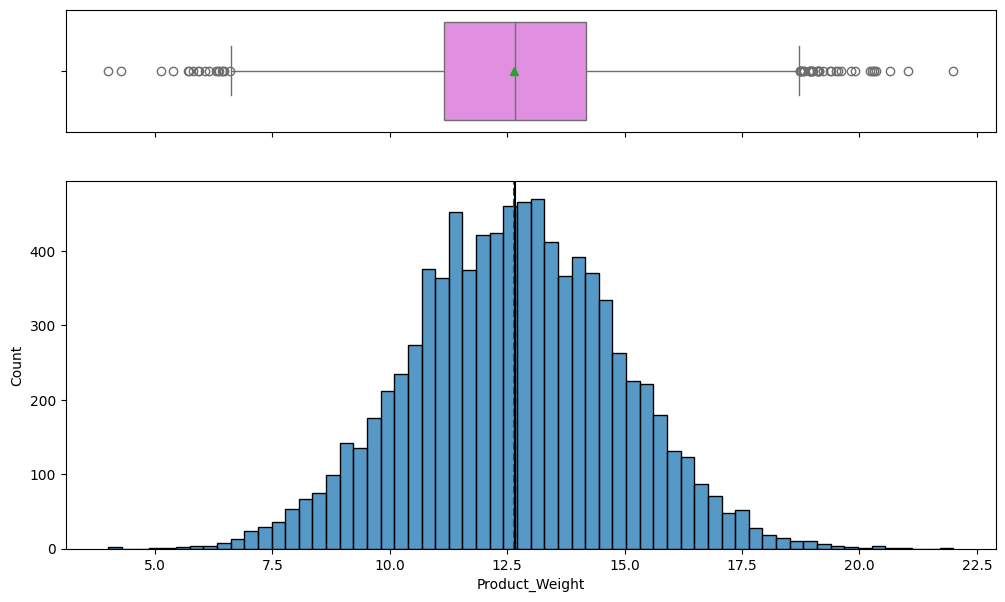

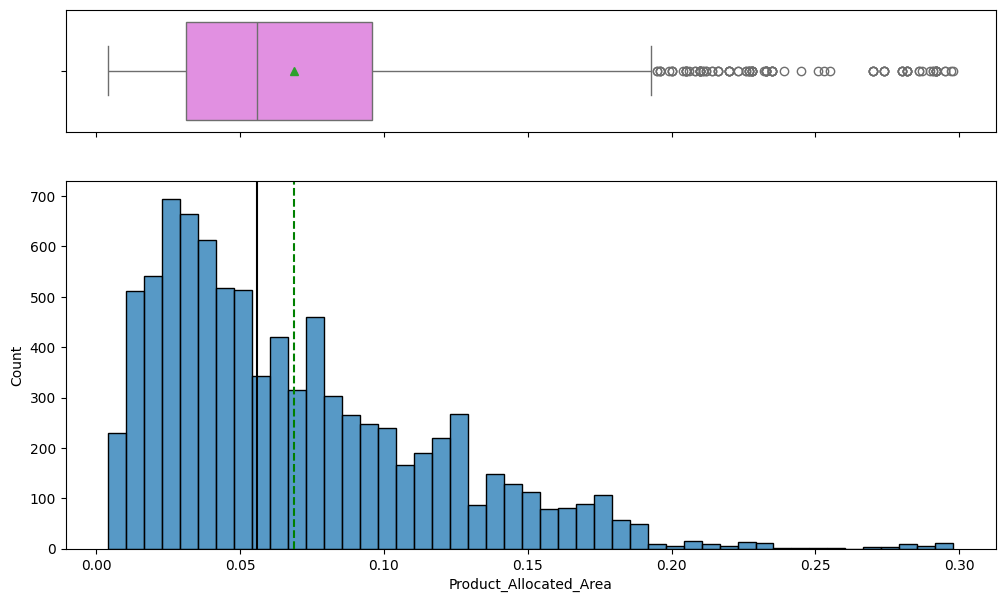

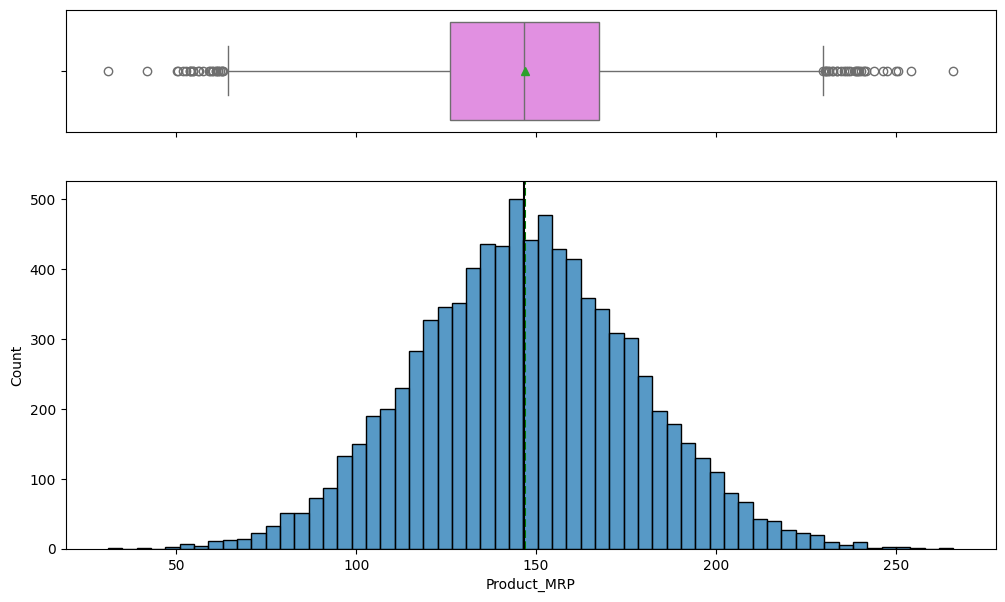

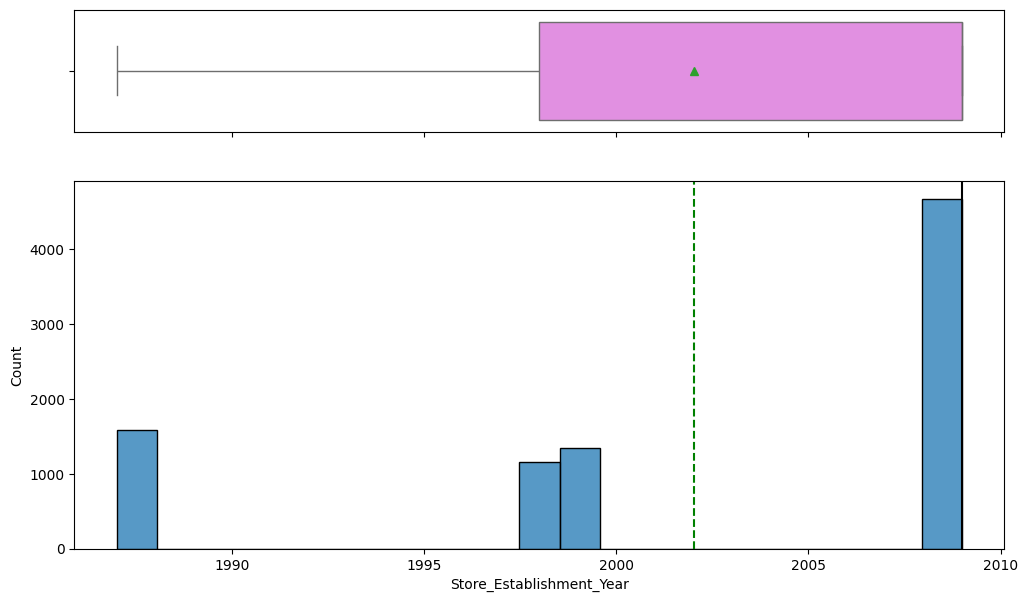

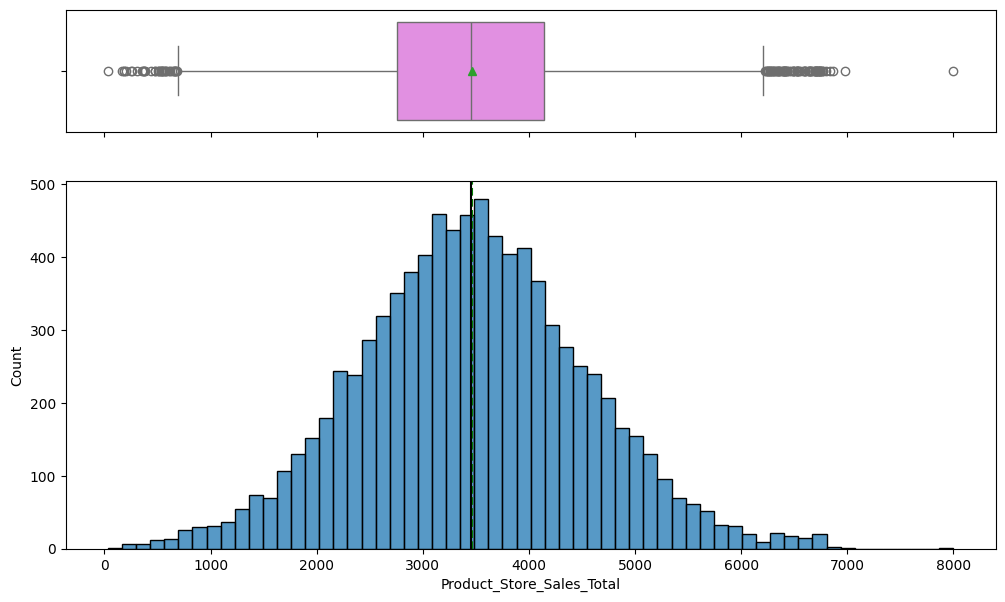

In [15]:
for feature in data.select_dtypes(include=np.number).columns:
   histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None)

# Inference:

1. There are only 5 numerical features in this dataset: Product_Weight, Product_Allocated_Area, Product_MRP, Store_Establishment_Year, and Product_Store_Sales_Total.
2. Product_Weight and Product_MRP are mostly symmetrical, Product_Allocated_Area and Product_Store_Sales_Total are slightly right-skewed, and Store_Establishment_Year is heavily left-skewed with many stores established in 2009.

#Outlier detection Mode

**To Do:**


Inorder to detect the outlier , Creating a Python function that uses the Interquartile Range (IQR) method to identify outliers. This function will take a Series (numerical feature) as input and return the values identified as outliers.

In [16]:
def find_outliers_iqr(series):
    """
    Calculates outliers using the Interquartile Range (IQR) method.

    Args:
        series (pd.Series): The input numerical series.

    Returns:
        pd.Series: A series containing the identified outliers.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

In [17]:
#import pandas as pd

#kart = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/ModelDeployment/SuperKart.csv")
data = kart.copy()

# Re-define numerical_features to ensure it's available
numerical_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']

for feature in numerical_features:
    outliers = find_outliers_iqr(data[feature])
    if not outliers.empty:
        print(f"Outliers for {feature}:")
        print(f"Number of outliers: {len(outliers)}")
        display(outliers)
        print("\n" + "-" * 50 + "\n")
    else:
        print(f"No outliers found for {feature}." + "\n" + "-" * 50 + "\n")

Outliers for Product_Weight:
Number of outliers: 54


,Product_Weight
221,19.22
231,21.04
394,18.82
551,19.37
630,19.12
701,20.35
736,5.81
794,18.94
891,20.22
1193,19.13



--------------------------------------------------

Outliers for Product_Allocated_Area:
Number of outliers: 104


,Product_Allocated_Area
7,0.286
124,0.210
349,0.280
392,0.205
422,0.208
...,...
8282,0.233
8283,0.251
8464,0.216
8523,0.223



--------------------------------------------------

Outliers for Product_MRP:
Number of outliers: 57


,Product_MRP
21,236.09
88,231.55
285,246.35
428,232.41
657,241.63
846,54.69
1252,231.07
1398,239.49
1400,56.01
1434,50.42



--------------------------------------------------

No outliers found for Store_Establishment_Year.
--------------------------------------------------

Outliers for Product_Store_Sales_Total:
Number of outliers: 119


,Product_Store_Sales_Total
21,6643.63
221,6275.29
227,536.20
285,6707.04
294,6541.04
...,...
8397,6636.30
8490,6318.47
8496,6657.74
8627,657.14



--------------------------------------------------



**#Inference**

1. As we can infer there are multiple outliers detected for certain numerical feature of the dataset.
2. The treatment of these outliers will be done in further steps.

**Next Steps:**

Univariate analysis to be done on the categorical features too.

In [18]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [19]:
#function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### Univariate Analysis of Categorical Features

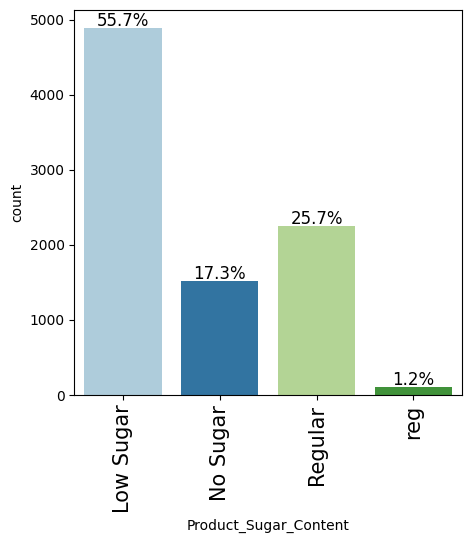

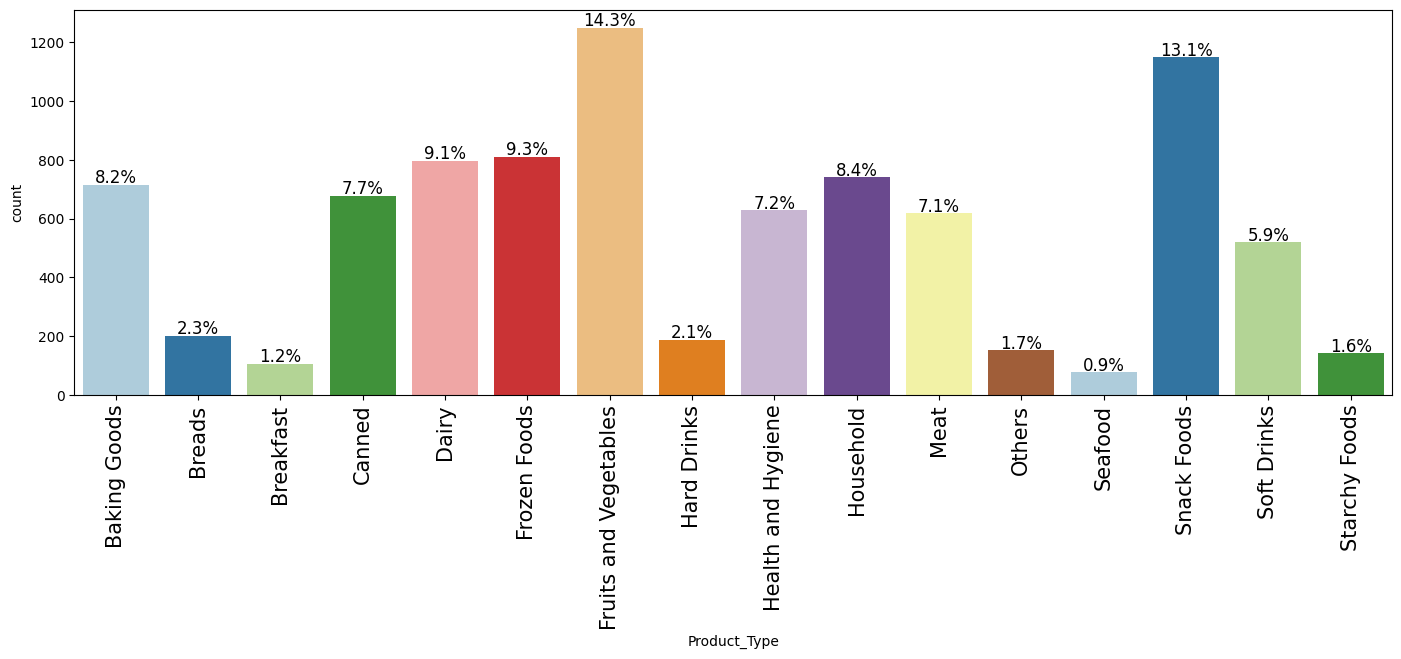

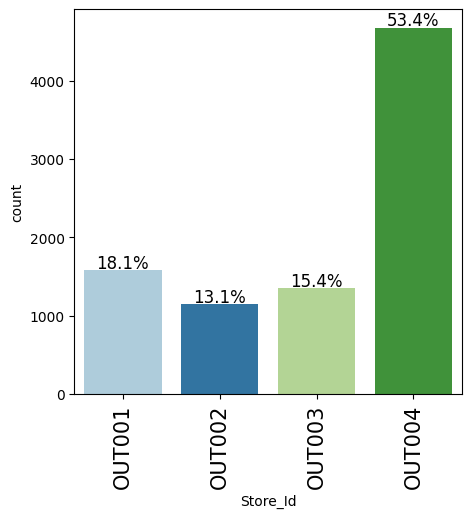

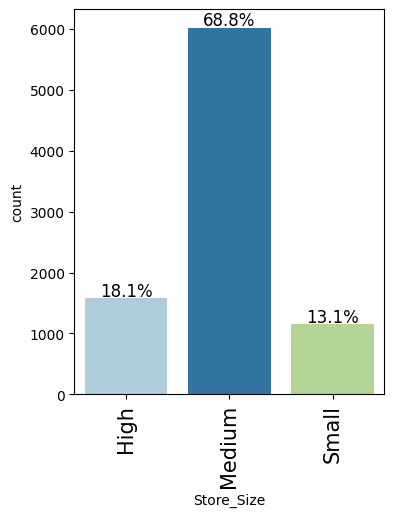

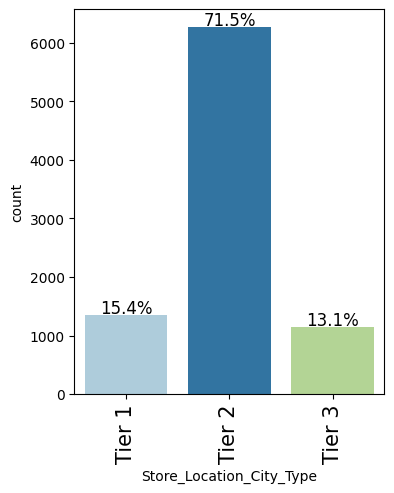

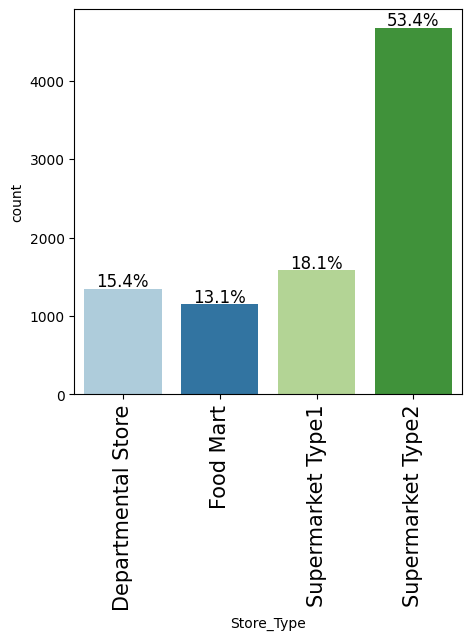

In [20]:
categorical_features = data.select_dtypes(include='object').columns.tolist()
# Exclude Product_Id as it has too many unique values for meaningful bar plots
categorical_features.remove('Product_Id')

for feature in categorical_features:
    labeled_barplot(data, feature, perc=True)

#Inference:


1. The labeled bar plots show that 'Low Sugar' is the most common Product_Sugar_Content,

2. 'Fruits and Vegetables' and 'Snack Foods' are the most frequent Product_Types,

3.  'OUT004' is the most represented Store_Id,
4. 'Medium' is the prevalent Store_Size,
5. most stores are in 'Tier 2'
6. Store_Location_City_Types, and 'Supermarket Type2' is the most common Store_Type.

### Bivariate Analysis: Categorical Features vs. Product_Store_Sales_Total

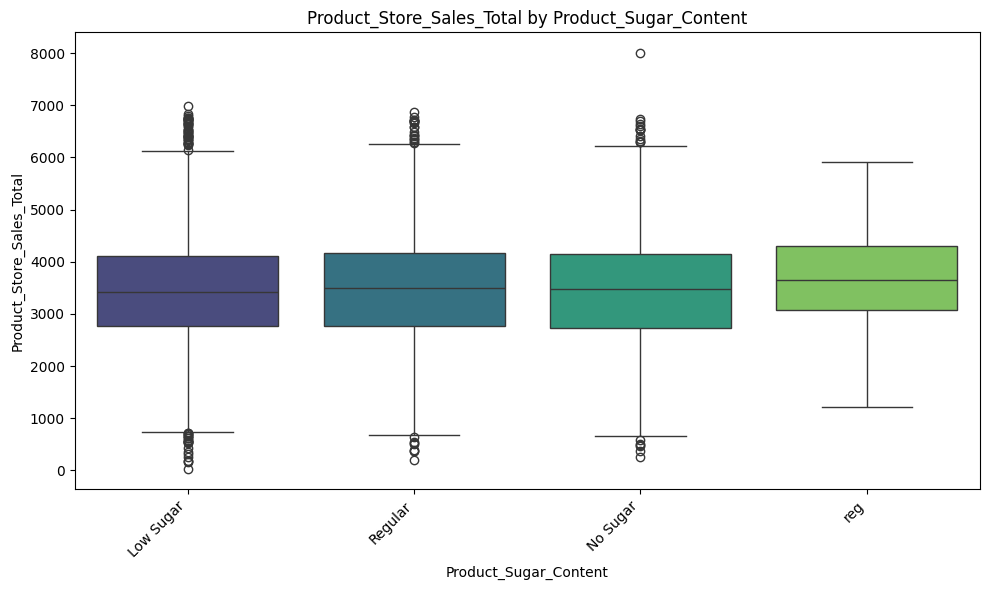

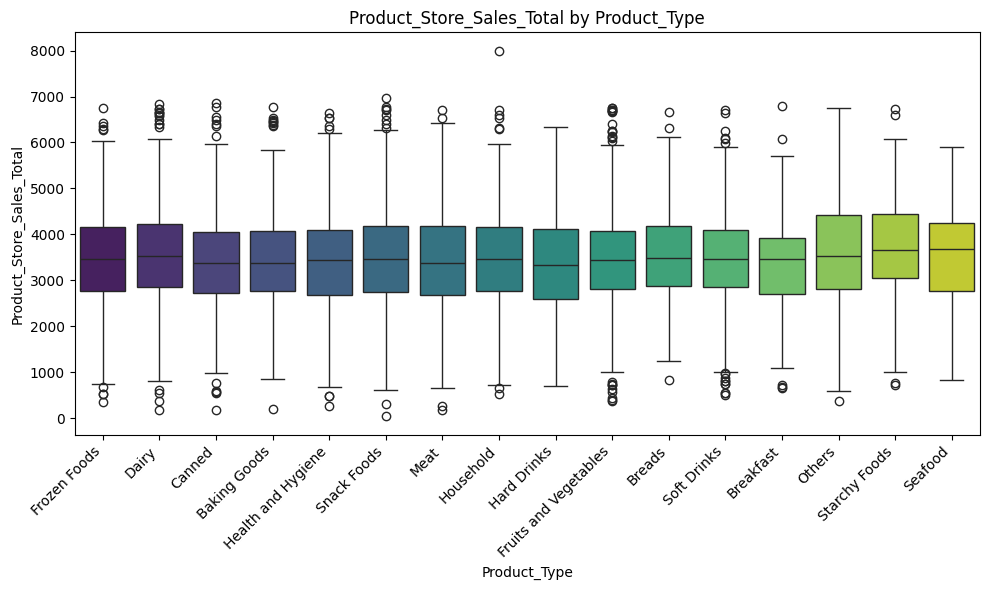

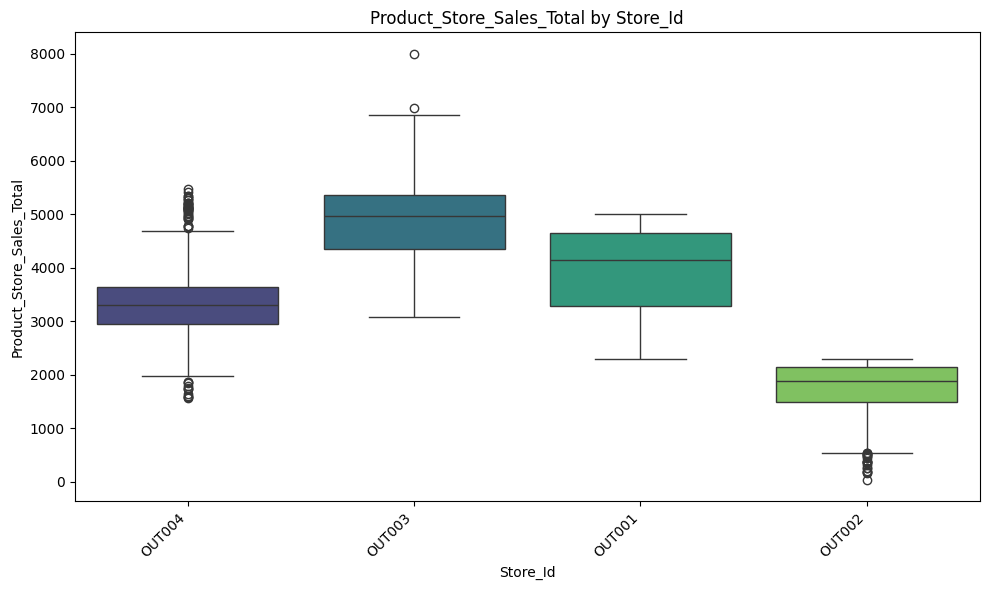

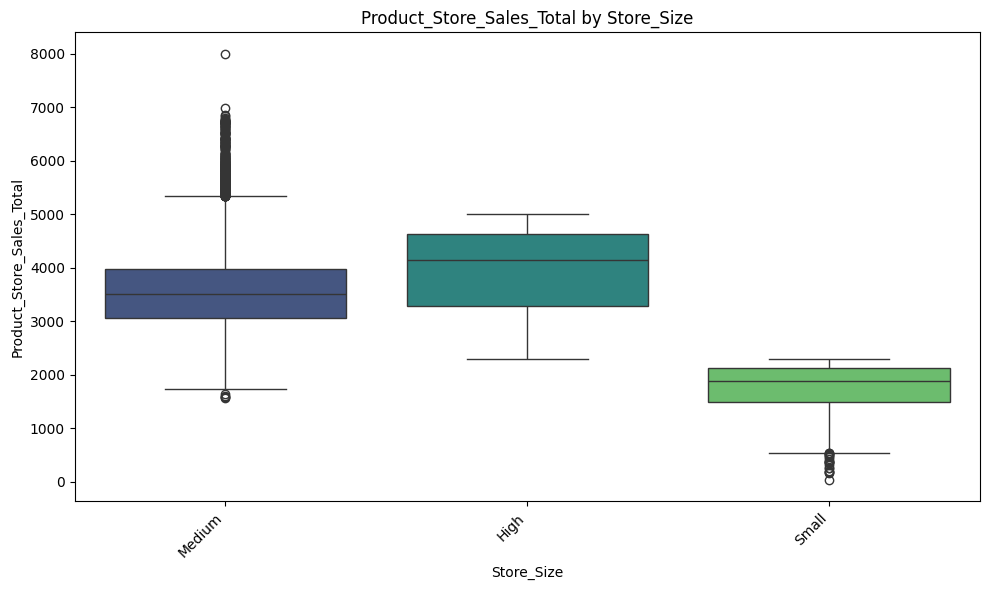

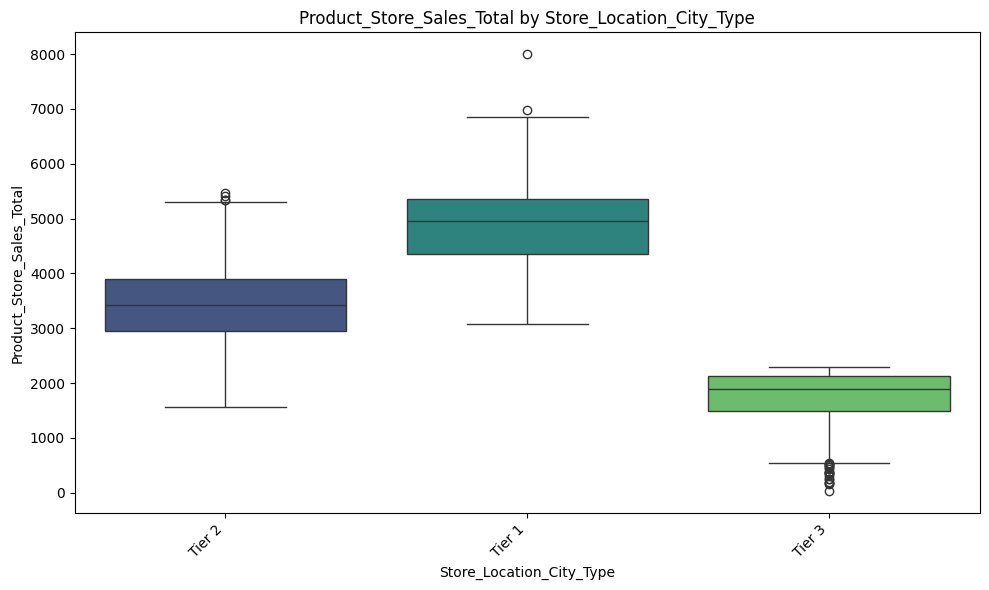

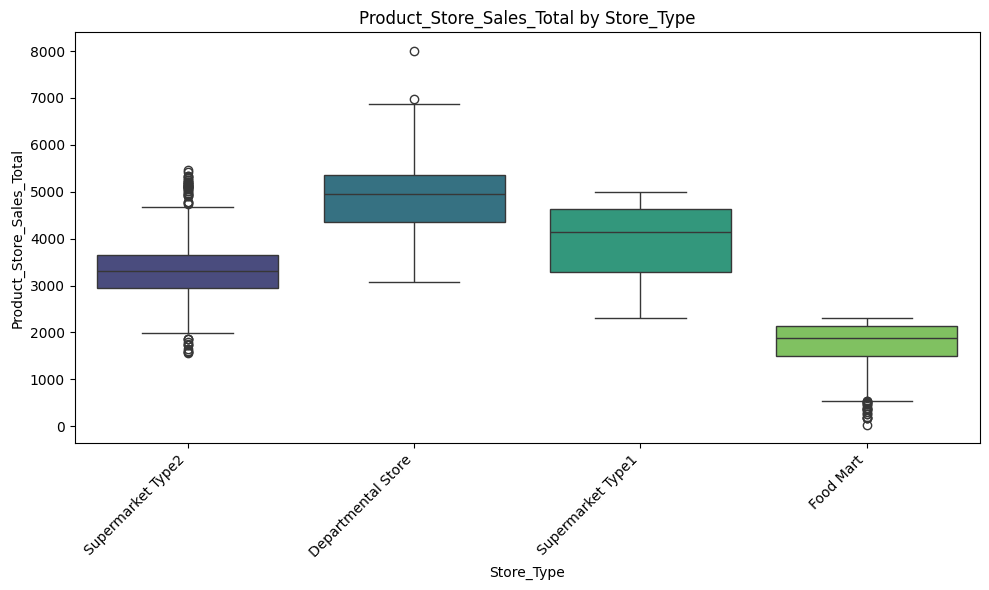

In [21]:
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=feature, y='Product_Store_Sales_Total', data=data, palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Product_Store_Sales_Total by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Product_Store_Sales_Total')
    plt.tight_layout()
    plt.show()


#Inference:
1.From the box plots, Departmental Store and Supermarket Type2 generally show higher sales compared to other store types,

2. High and Medium sized stores outperform Small ones,

3. Tier 2 city locations are associated with wider sales ranges and often higher median sales,

4. product types like Dairy and Fruits and Vegetables also tend to have higher sales.

## Bivariate Analysis

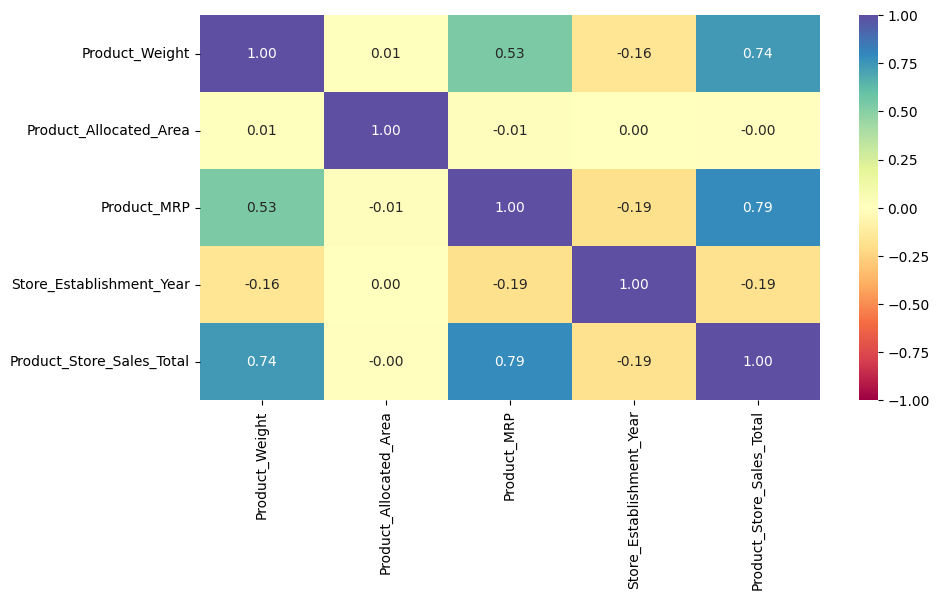

In [22]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

#Inference:

1.From the correlation matrix, it can be inferred that Product_MRP and Product_Allocated_Area have positive correlations with Product_Store_Sales_Total,

2.Product_Weight and Store_Establishment_Year show very weak linear relationships with sales.

### Bivariate Analysis: Numerical Features vs. Product_Store_Sales_Total

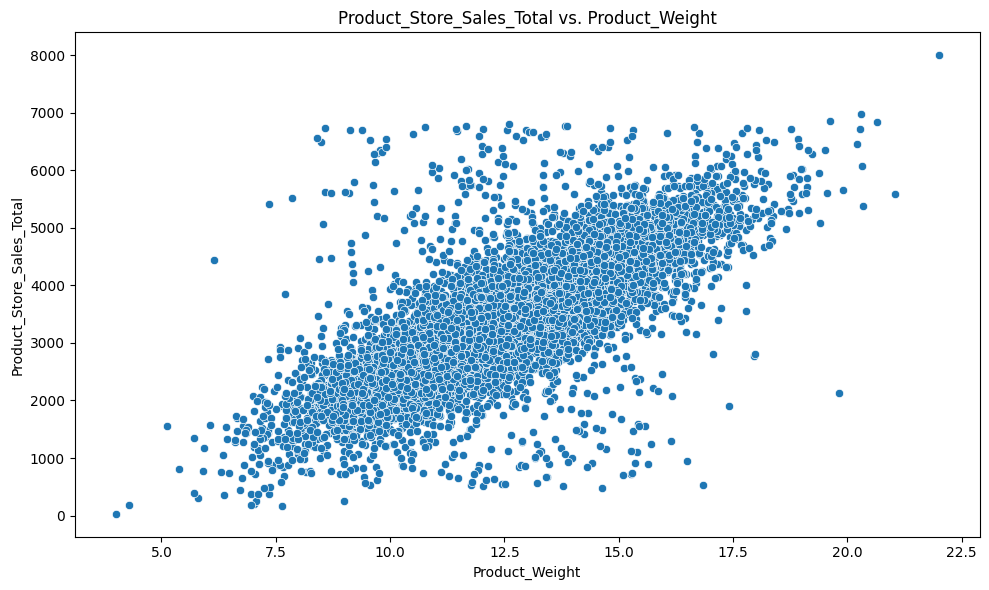

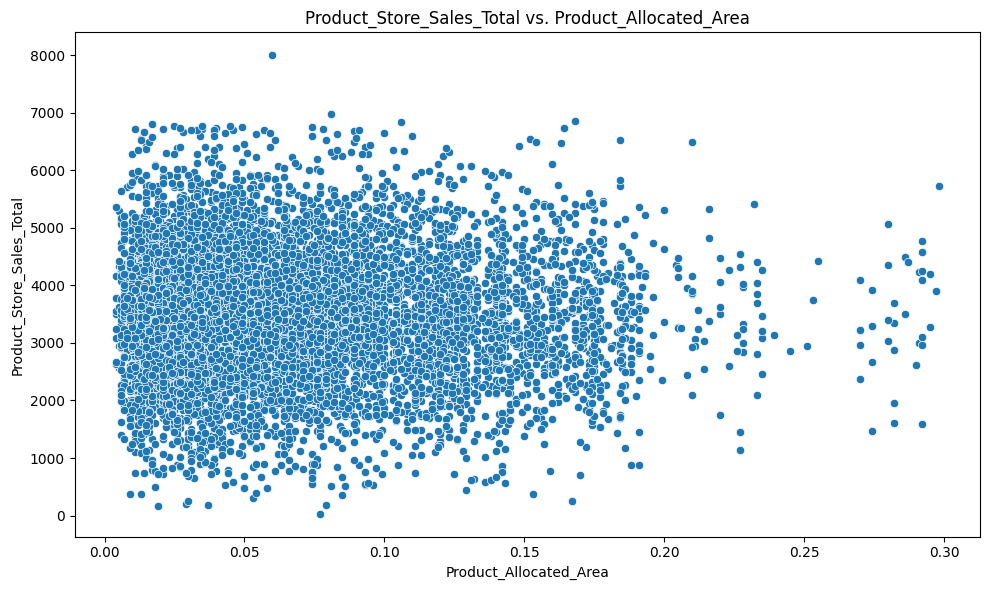

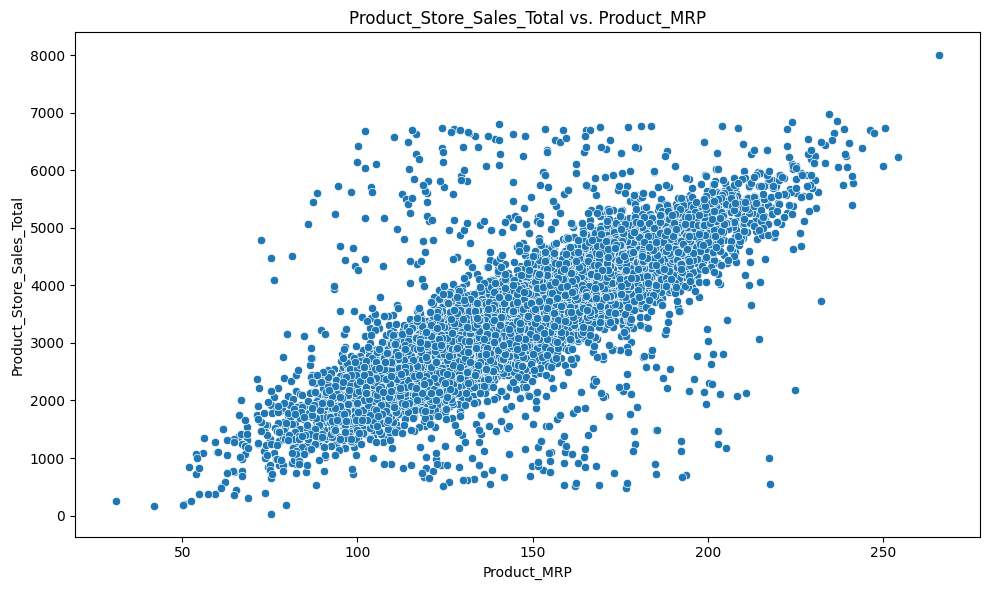

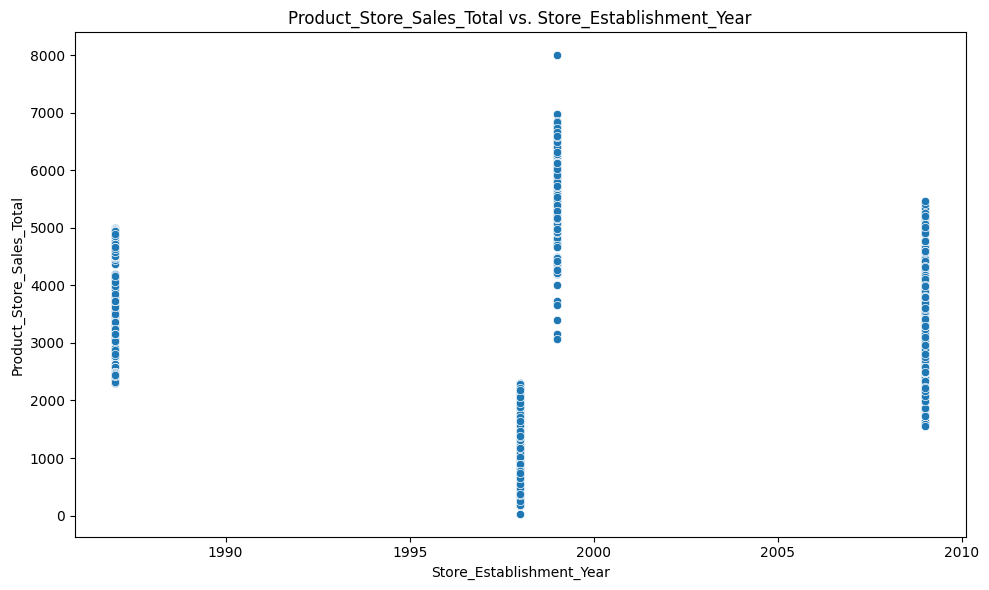

In [23]:
numeric_features = data.select_dtypes(include=np.number).columns.tolist()
# Exclude the target variable from the list of features for scatter plots
numeric_features.remove('Product_Store_Sales_Total')

for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=feature, y='Product_Store_Sales_Total', data=data)
    plt.title(f'Product_Store_Sales_Total vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Product_Store_Sales_Total')
    plt.tight_layout()
    plt.show()

#Inference:
1. Although the inference from Scatter plot is similar to the heatmap
2. heatmap showed us how strong a linear correlation is, a scatter plot showed us what that relationship looks like in detail, including nuances that a single correlation coefficient might miss.

#Identify which product type generates more revenue

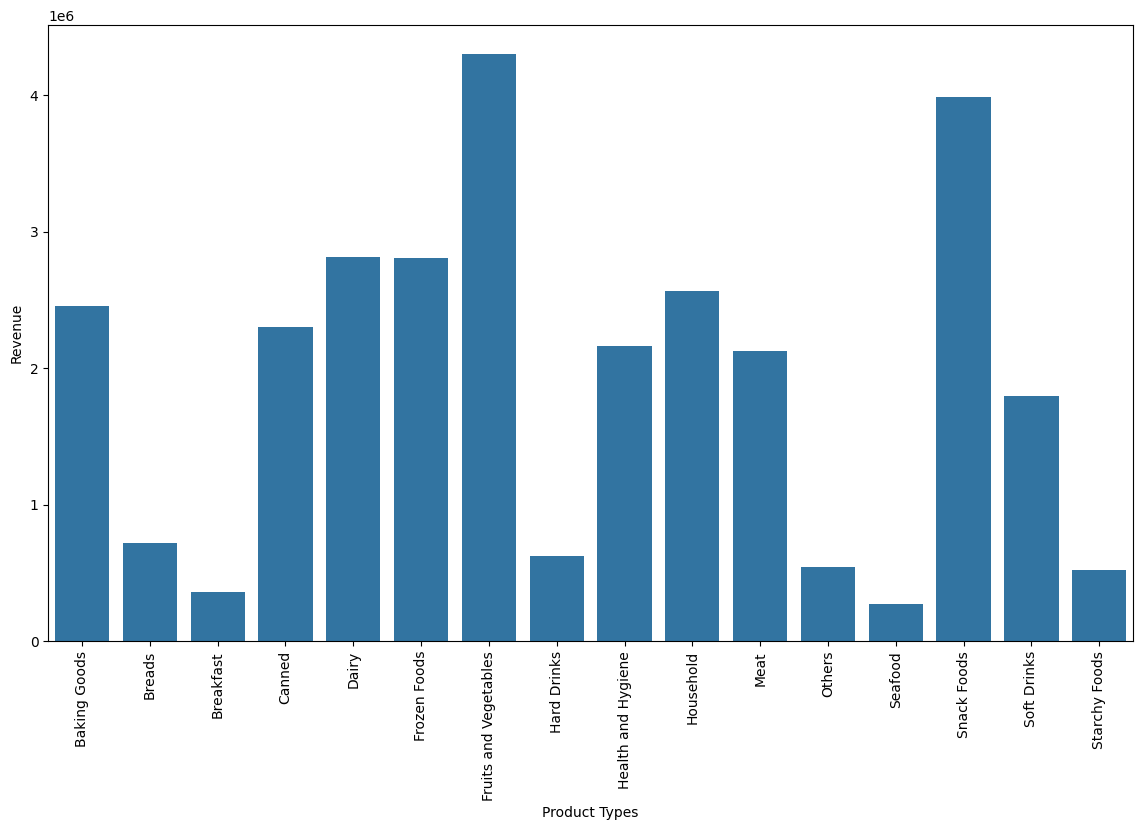

In [24]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

#Inference:
1.From the bar plot showing total revenue by product type, it is clear that Snack Foods generate the highest revenue, closely followed by Fruits and Vegetables.
2.Baking Goods and Canned products also contribute substantially.
3.Conversely, categories like Seafood and Breakfast contribute the least to the overall sales revenue.

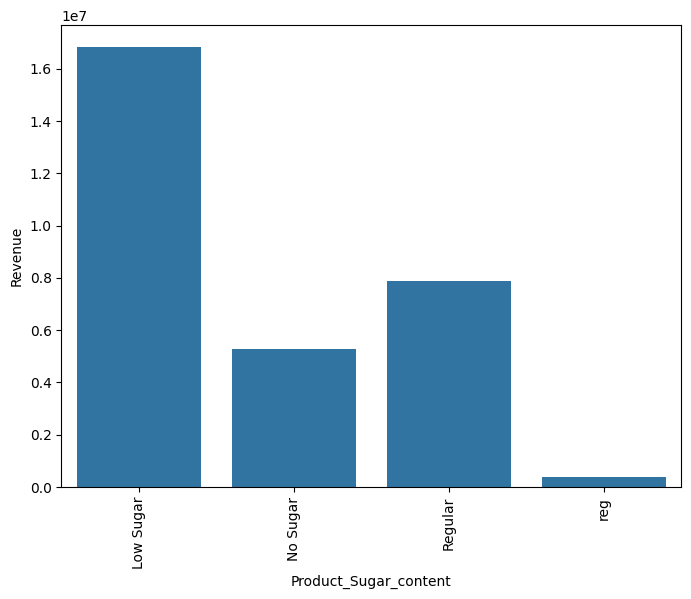

In [25]:
df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()  #Complete the code to perform a groupby on Product_Sugar_Content and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()

#Inference:
1. products with 'Low Sugar' content generate the highest total sales revenue, significantly outperforming products categorized as 'Regular' or 'No Sugar'.
2.  The 'reg' category contributes the least, which might be a data anomaly or a very small product segment.

##Determine which type of stores and locations the revenue generation is more.

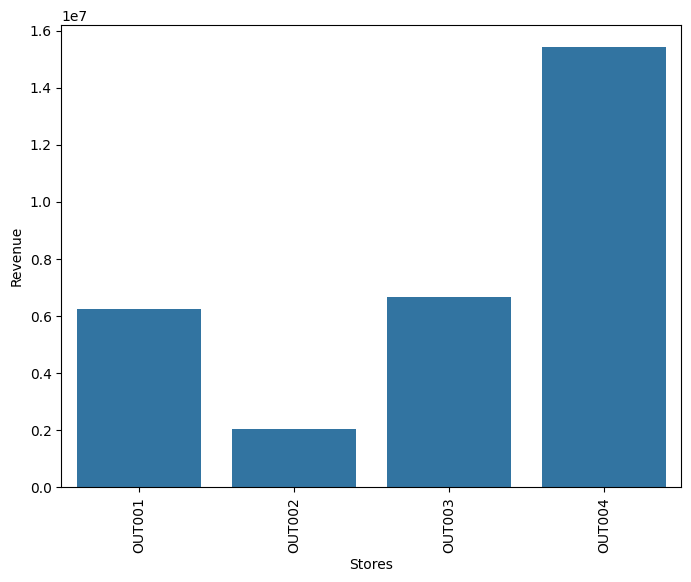

In [26]:
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Complete the code to perform a groupby on Store_Id and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

#Inference:

 Store with ID - OUT004 generates the highest total sales revenue by a significant margin, followed by OUT003 and OUT001. Store OUT002 appears to contribute the least to overall sales.

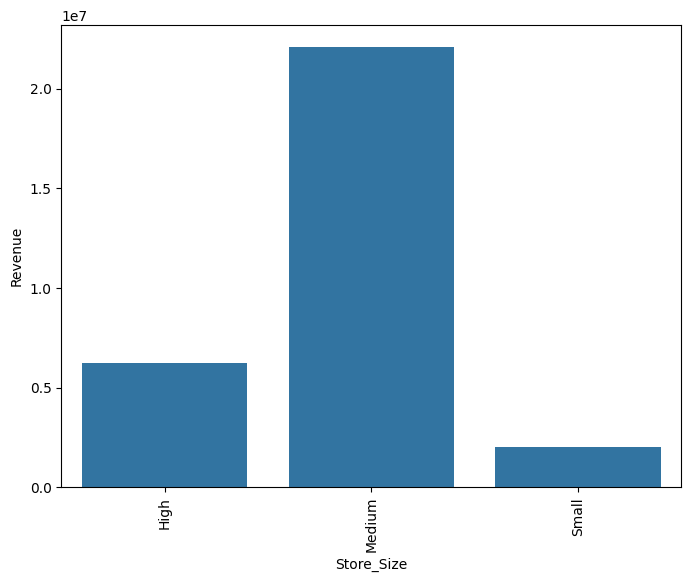

In [27]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Complete the code to perform a groupby on Store_Size and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

#Inference :
Medium-sized stores generate the highest total sales revenue, significantly outperforming both High and Small-sized stores. Small stores contribute the least to overall sales.

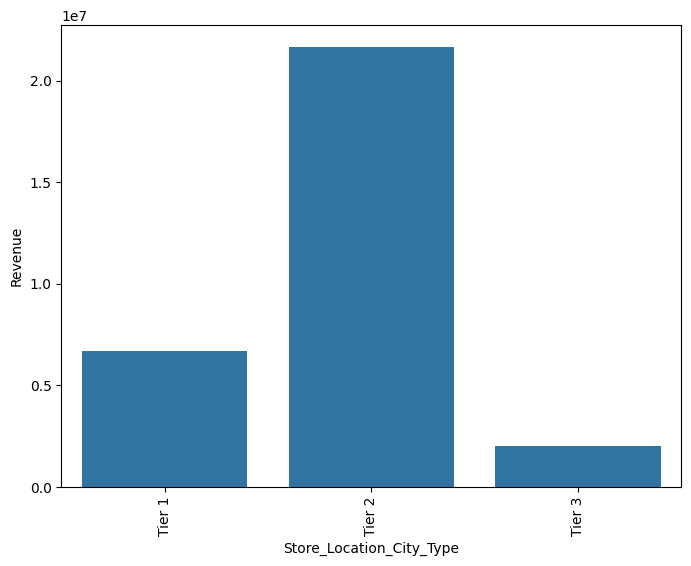

In [28]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Complete the code to perform a groupby on Store_Location_City_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

#Inference:

1. From the bar plot showing total revenue by store location city type, it can be inferred that stores in 'Tier 2' cities generate the highest sales revenue, significantly surpassing 'Tier 1' and 'Tier 3' cities.
2.  'Tier 3' cities contribute the least to overall sales.

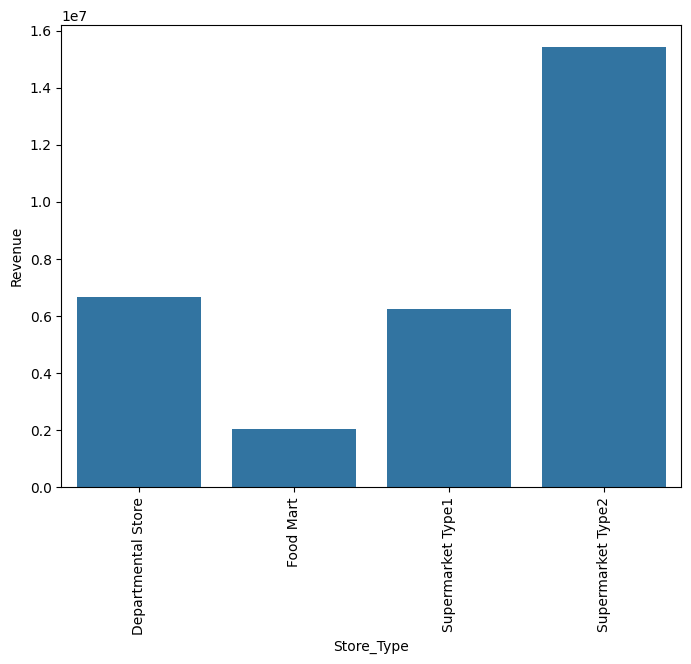

In [29]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"
].sum() #Complete the code to perform a groupby on Store_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

#Inference:

1. 'Supermarket Type2' stores generate the highest sales revenue, significantly outperforming 'Departmental Store', 'Supermarket Type1', and 'Food Mart' stores.
2. 'Food Mart' stores contribute the least to overall sales.

##Distribution of our target variable i.e Product_Store_Sales_Total with the other categorical columns

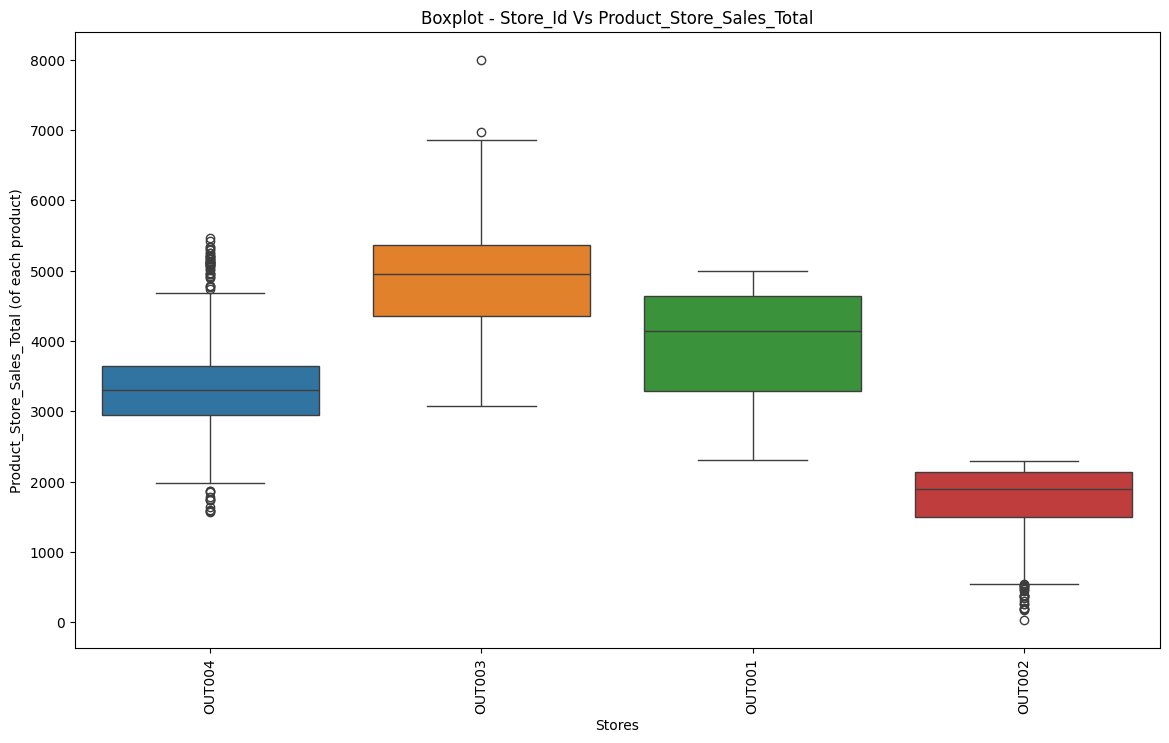

In [30]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

#Inference  from above boxplot:

1. Store OUT004 not only has the highest total sales, but also exhibits a higher median and a wider spread of sales values, indicating consistently strong performance across many products.
2. Stores OUT003 and OUT001 show moderate sales, while Store OUT002 has the lowest median sales and a more compact distribution, suggesting lower individual product sales and overall revenue.

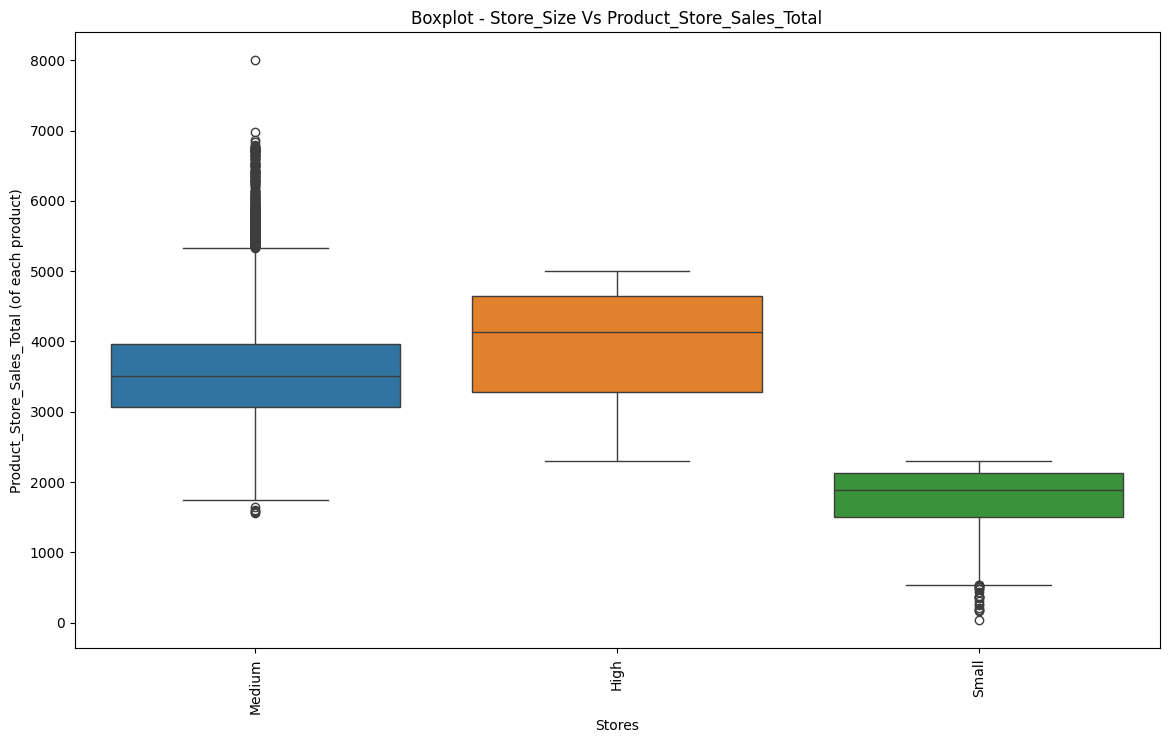

In [31]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size") #Complet the code to plot the boxplot with x as Store_Size , y as Product_Store_Sales_Total and hue as Store_Size
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

#Inference :
1. From the boxplot, we can infer that 'Medium' sized stores typically have higher median sales and a broader distribution of individual product sales compared to 'High' and 'Small' sized stores.
2. 'Small' stores generally show the lowest median sales and a more constrained range of sales values.
3. This indicates that medium-sized stores are strong performers in terms of both overall revenue contribution and individual product sales potential.

##Finding relationship between columns:

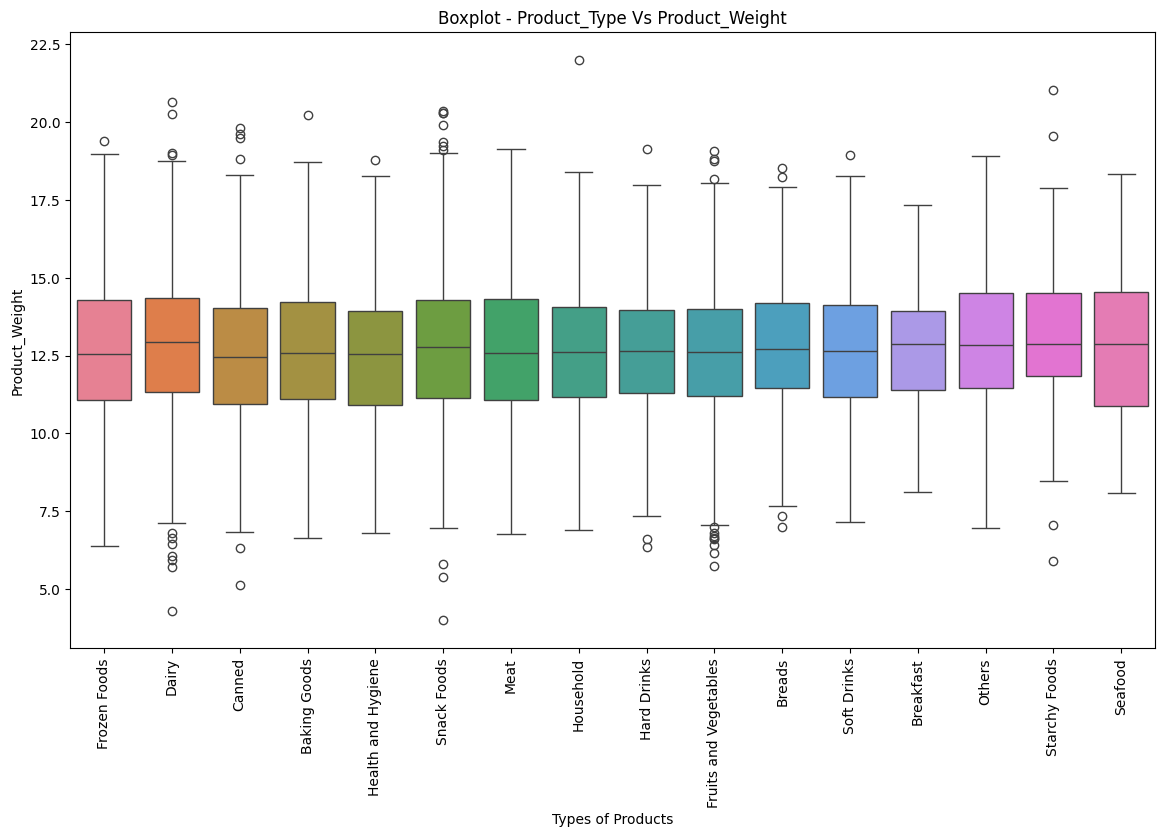

In [32]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type") #Complete the code to plot the boxplot with x as Product_Type , y as Product_Weight and hue as Product_Type
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

#Inference:

1. Product_Type versus Product_Weight, we can observe that the distribution of product weight varies significantly across different product types.
2.  Some product types, such as 'Snack Foods' or 'Fruits and Vegetables', might show a wider range of weights, while others like 'Seafood' or 'Breakfast' might have a more concentrated weight distribution.
3.Additionally, the median product weight can differ substantially between categories, indicating that certain product types inherently tend to be heavier or lighter than others.
4. Outliers might also be present, suggesting some products within a category have unusually high or low weights.

# **Data Preprocessing**

## **Replacing the values in the Product_Sugar_Content column**

We can observe that in the Product_Sugar_Content column, there are 3 types - Low Sugar, Regular and reg.

It seems quite obvious that Regular and reg are referring to the same category. So let's replace reg with Regular.

In [33]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

In [34]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.
validating if they are having any relationship with the other columns or not

In [35]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


### Relationship between Product_Id_char and Product_Store_Sales_Total

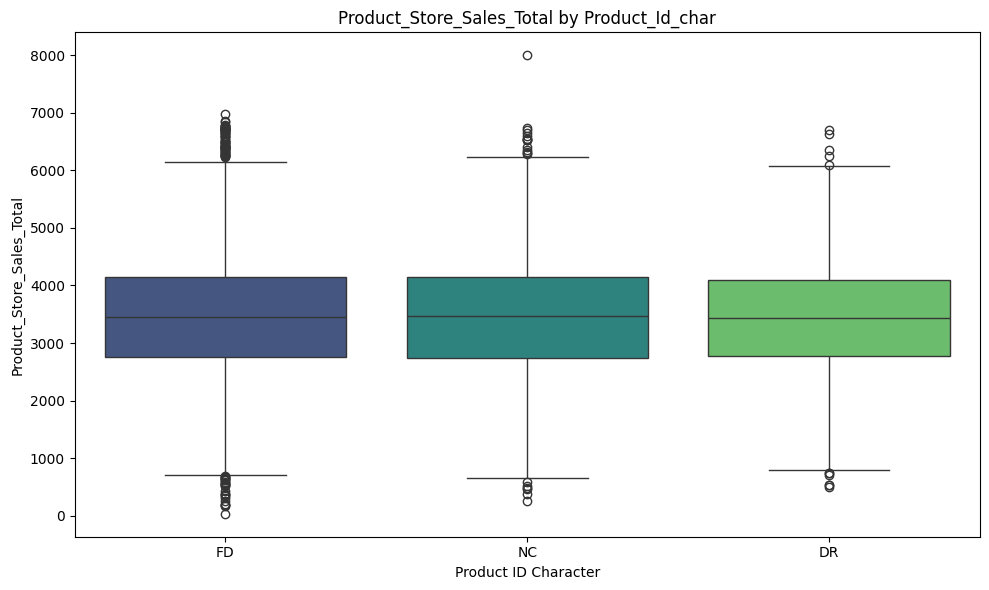

In [36]:
plt.figure(figsize=[10, 6])
sns.boxplot(x='Product_Id_char', y='Product_Store_Sales_Total', data=data, palette='viridis')
plt.title('Product_Store_Sales_Total by Product_Id_char')
plt.xlabel('Product ID Character')
plt.ylabel('Product_Store_Sales_Total')
plt.tight_layout()
plt.show()

#Inference:

1. Different prefixes, such as 'FD' and 'NC', show distinct distributions and median sales figures. For instance, products with 'FD' (Food) prefixes tend to have a wider range and higher median sales, while products with 'NC' (Non-Consumable) prefixes show generally lower sales.

2. This suggests that the product category, as indicated by the Product_Id_char, is an important factor influencing sales revenue.

**More Preprocessing steps**

1.  Feature Engineering for Store Age - as it provides meaningful numerical feature for the model.

2. Categorical Feature Encoding:

*One-Hot Encoding* : Convert nominal categorical features such as Product_Sugar_Content, Product_Type, Store_Id, Store_Location_City_Type, Store_Type, and the newly created Product_Id_char into numerical format using one-hot encoding.


*Ordinal Encoding*: For ordinal categorical features like Store_Size (Small, Medium, High), convert them into numerical representations that reflect their inherent order.

*Numerical Feature Scaling*:

Apply scaling (e.g., StandardScaler or MinMaxScaler) to numerical features such as Product_Weight, Product_Allocated_Area, Product_MRP, and the engineered Store_Age. This ensures that features with larger numerical ranges do not disproportionately influence the model.

*Target Variable Transformation*:

Since Product_Store_Sales_Total appears slightly right-skewed, a transformation like a log transformation could be applied to make its distribution more Gaussian-like. This can improve the performance of some regression models.

### **1. Separating features and target**

In [37]:
# Separating target variable and other variables
X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']

In [38]:
import datetime

current_year = datetime.datetime.now().year
print(f"The current year is: {current_year}")

The current year is: 2026


### **2. Feature Engineering: Creating 'Store_Age'**

Since current year is 2026, using the same to find the age of the store

In [39]:
# Creating Store_Age feature
X['Store_Age'] = current_year - X['Store_Establishment_Year']

# Dropping the original 'Store_Establishment_Year' column
X = X.drop('Store_Establishment_Year', axis=1)

In [40]:
print('x value is ',X.head())


x value is    Product_Id  Product_Weight Product_Sugar_Content  Product_Allocated_Area  \
0     FD6114           12.66             Low Sugar                   0.027   
1     FD7839           16.54             Low Sugar                   0.144   
2     FD5075           14.28               Regular                   0.031   
3     FD8233           12.10             Low Sugar                   0.112   
4     NC1180            9.57              No Sugar                   0.010   

         Product_Type  Product_MRP Store_Id Store_Size  \
0        Frozen Foods       117.08   OUT004     Medium   
1               Dairy       171.43   OUT003     Medium   
2              Canned       162.08   OUT001       High   
3        Baking Goods       186.31   OUT001       High   
4  Health and Hygiene       123.67   OUT002      Small   

  Store_Location_City_Type          Store_Type Product_Id_char  Store_Age  
0                   Tier 2   Supermarket Type2              FD         17  
1                 

### **3. Ordinal Encoding: 'Store_Size'**

In [41]:
# Ordinal encoding for Store_Size
size_map = {'Small': 0, 'Medium': 1, 'High': 2}
X['Store_Size'] = X['Store_Size'].map(size_map)

## 4. Outlier Detection & Treatment

In [42]:
numerical_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
print(numerical_features)

['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']


## To detect the Outlier , creating a Detection Function (IQR)


Creating a Python function that uses the Interquartile Range (IQR) method to identify outliers. This function will take a Series (numerical feature) as input and return the values identified as outliers.


# To Dos:
1. Defining a Python function `capp_outliers_iqr` to cap outliers using the Interquartile Range (IQR) method. Apply this function to the 'Product_Weight', 'Product_Allocated_Area', 'Product_MRP', and 'Product_Store_Sales_Total' features in the `data` DataFrame, updating the DataFrame with the capped values.

2. Afterward, generate histograms and box plots for these capped features to visualize their distributions, ensuring clear titles and legends for each plot.

## Define Outlier Capping Function


1. Creating a Python function, `capp_outliers_iqr`, that takes a pandas Series (numerical feature) as input and returns a new Series with outliers capped using the Interquartile Range (IQR) method.

2. The function should calculate Q1, Q3, IQR, and then define lower and upper bounds (Q1 - 1.5*IQR and Q3 + 1.5*IQR).

3. Any values below the lower bound will be replaced by the lower bound, and any values above the upper bound will be replaced by the upper bound.


In [43]:
def capp_outliers_iqr(series):
    """
    Caps outliers in a pandas Series using the Interquartile Range (IQR) method.

    Args:
        series (pd.Series): The input numerical series.

    Returns:
        pd.Series: A new series with outliers capped.
    """
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a copy to avoid modifying the original series
    capped_series = series.copy()
    capped_series[capped_series < lower_bound] = lower_bound
    capped_series[capped_series > upper_bound] = upper_bound

    return capped_series

In [44]:
features_to_cap = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Product_Store_Sales_Total']

for feature in features_to_cap:
    data[feature] = capp_outliers_iqr(data[feature])
    print(f"Outliers in '{feature}' capped.")

print("\nUpdated data head after capping:")
display(data.head())

Outliers in 'Product_Weight' capped.
Outliers in 'Product_Allocated_Area' capped.
Outliers in 'Product_MRP' capped.
Outliers in 'Product_Store_Sales_Total' capped.

Updated data head after capping:


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


** Next steps**

1. Visualize the distributions of the features after capping the outliers.

2. The `histogram_boxplot` function is already defined for this purpose and will display both a histogram and a boxplot for each specified numerical feature, allowing for an immediate comparison of the distributions before and after capping.




Distribution of 'Product_Weight' after outlier capping:

Distribution of 'Product_Allocated_Area' after outlier capping:

Distribution of 'Product_MRP' after outlier capping:

Distribution of 'Product_Store_Sales_Total' after outlier capping:


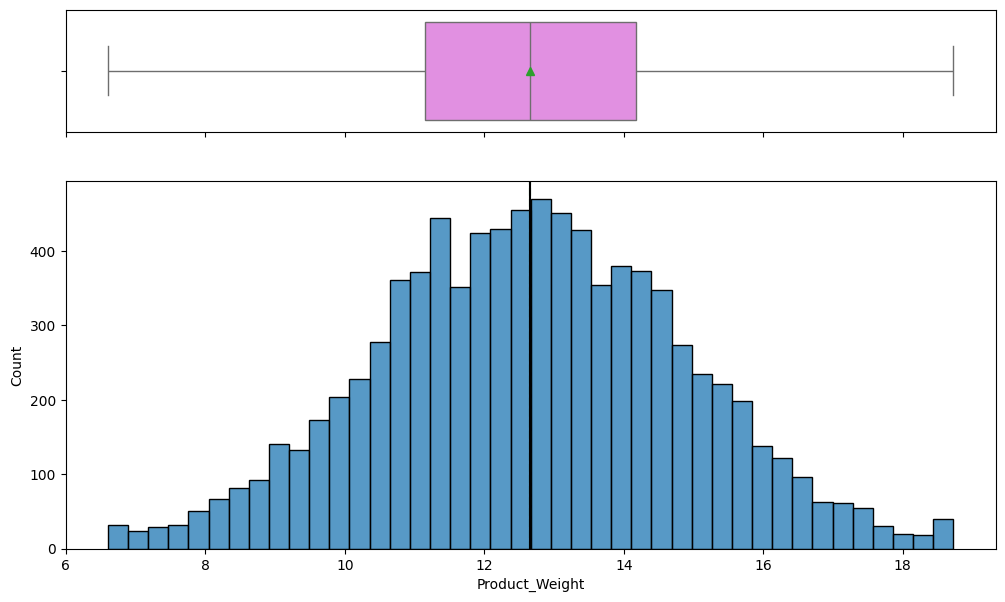

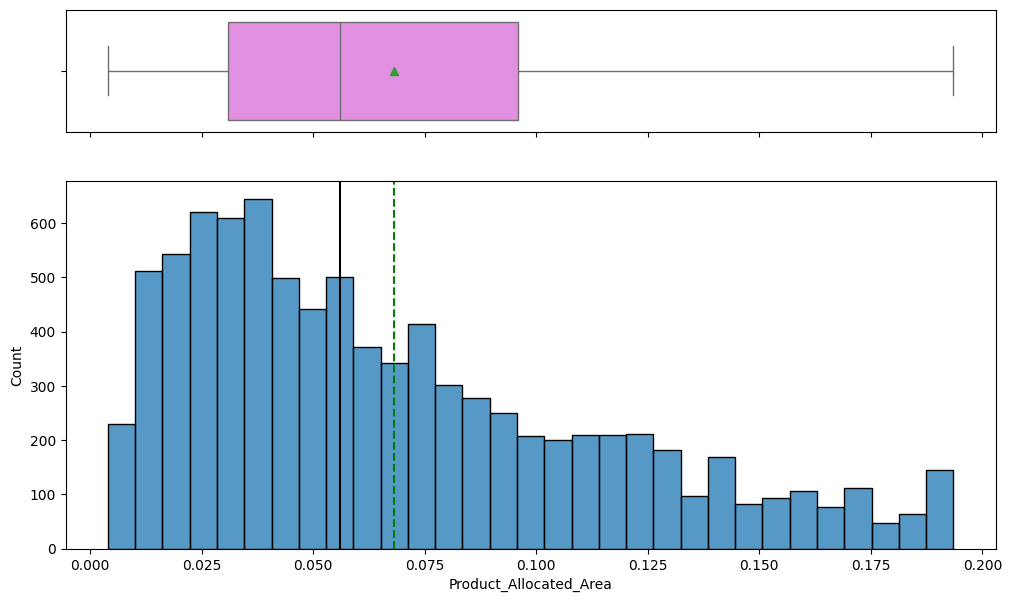

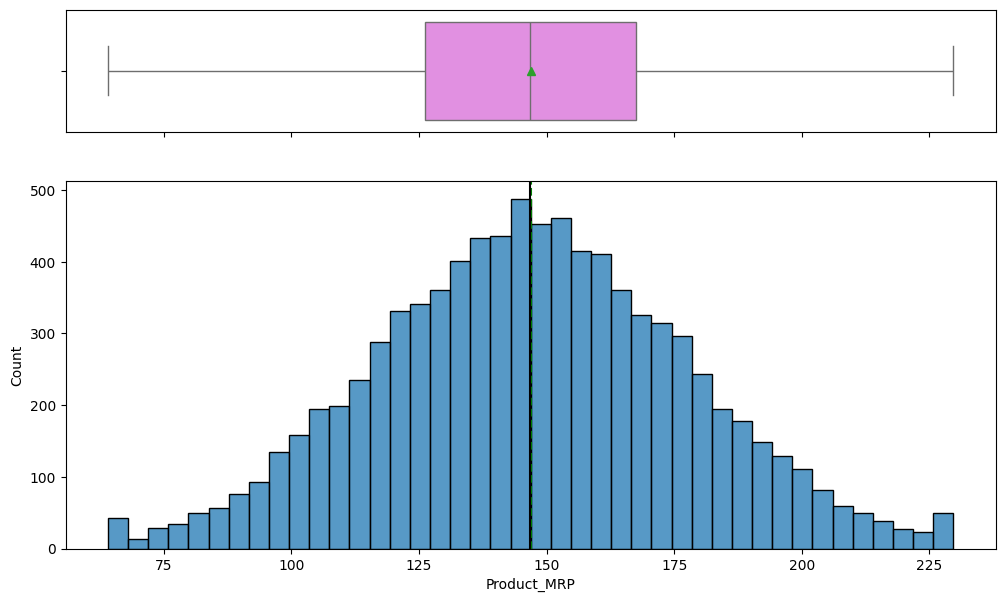

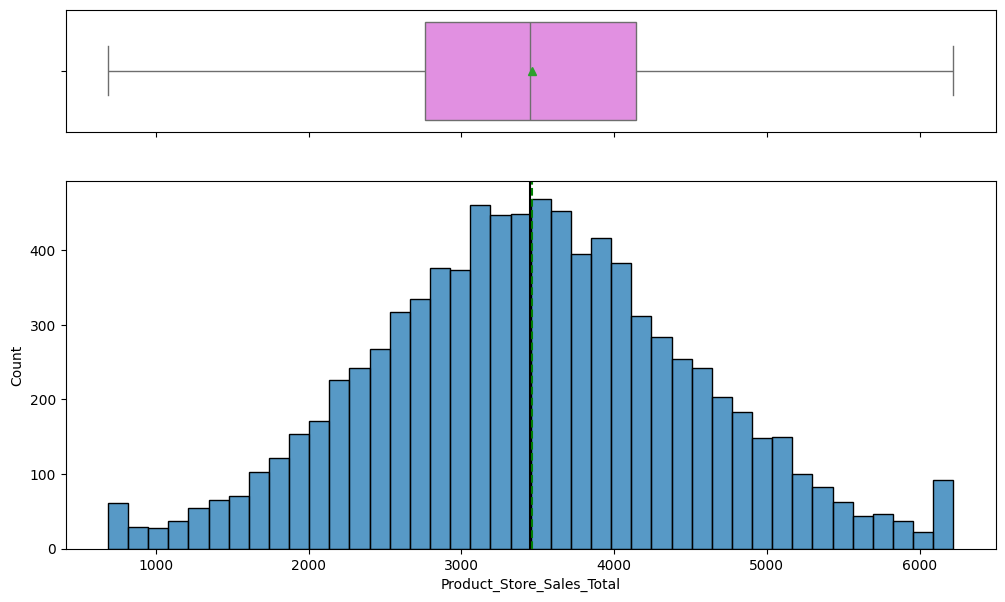

In [45]:
for feature in features_to_cap:
    print(f"\nDistribution of '{feature}' after outlier capping:")
    histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None)

### **4. Target Variable Transformation: Log transformation for `Product_Store_Sales_Total`**

In [46]:
# Applying log transformation to the target variable to handle skewness
y_transformed = np.log(y)

### **5. One-Hot Encoding and Numerical Feature Scaling**

In [47]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

# Identifying categorical and numerical features for further processing

# Dropping 'Product_Id' as 'Product_Id_char' is already created and it has too many unique values
if 'Product_Id' in X.columns:
    X = X.drop('Product_Id', axis=1)

# Identifying nominal categorical features (excluding 'Store_Size' as it's already encoded)
nominal_categorical_features = ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char']

# Identifying numerical features
# Include 'Store_Size' here as it's already numerically encoded and will be scaled
numerical_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age', 'Store_Size']

# Creating a column transformer for one-hot encoding and scaling
# Set sparse_output=False for OneHotEncoder to ensure a dense array output
column_transformers = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_categorical_features),
    (StandardScaler(), numerical_features),
    remainder='drop' # Drop any other columns not specified
)

# Apply transformations to the specified columns
X_processed = column_transformers.fit_transform(X)

# Get feature names from the applied transformers
transformed_feature_names = column_transformers.get_feature_names_out()

# Converting the processed array back to a DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=transformed_feature_names)

Note:

1. The ColumnTransformer is a powerful tool in scikit-learn that allows us to apply different transformers to different columns of your dataset simultaneously. This is crucial for data preprocessing because different types of features often require different scaling or encoding methods.

2. Nominal categorical features (like Product_Sugar_Content, Product_Type, Store_Id, etc.) are categories without any inherent order. Machine learning models typically require numerical input, so these need to be converted.

3. Numerical features (like Product_Weight, Product_Allocated_Area, Product_MRP, Store_Age, Store_Size) are already numeric but often have different scales and ranges. Many machine learning algorithms perform better when numerical input features are scaled to a standard range or distribution.

4. By using ColumnTransformer with these specifications, we ensure that all features are appropriately transformed into a suitable numerical format for the machine learning model, while preserving the integrity and meaning of each feature type.  

5. Also, all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s) in the np.hstack operation indicates a dimension mismatch between the two arrays you were trying to concatenate. - so applying sparse_output as false helped ensure all arrrays are of same dimension.

In [48]:
display(X_processed_df.head())

,onehotencoder__Product_Sugar_Content_Low Sugar,onehotencoder__Product_Sugar_Content_No Sugar,onehotencoder__Product_Sugar_Content_Regular,onehotencoder__Product_Type_Baking Goods,onehotencoder__Product_Type_Breads,onehotencoder__Product_Type_Breakfast,onehotencoder__Product_Type_Canned,onehotencoder__Product_Type_Dairy,onehotencoder__Product_Type_Frozen Foods,onehotencoder__Product_Type_Fruits and Vegetables,onehotencoder__Product_Type_Hard Drinks,onehotencoder__Product_Type_Health and Hygiene,onehotencoder__Product_Type_Household,onehotencoder__Product_Type_Meat,onehotencoder__Product_Type_Others,onehotencoder__Product_Type_Seafood,onehotencoder__Product_Type_Snack Foods,onehotencoder__Product_Type_Soft Drinks,onehotencoder__Product_Type_Starchy Foods,onehotencoder__Store_Id_OUT001,onehotencoder__Store_Id_OUT002,onehotencoder__Store_Id_OUT003,onehotencoder__Store_Id_OUT004,onehotencoder__Store_Location_City_Type_Tier 1,onehotencoder__Store_Location_City_Type_Tier 2,onehotencoder__Store_Location_City_Type_Tier 3,onehotencoder__Store_Type_Departmental Store,onehotencoder__Store_Type_Food Mart,onehotencoder__Store_Type_Supermarket Type1,onehotencoder__Store_Type_Supermarket Type2,onehotencoder__Product_Id_char_DR,onehotencoder__Product_Id_char_FD,onehotencoder__Product_Id_char_NC,standardscaler__Product_Weight,standardscaler__Product_Allocated_Area,standardscaler__Product_MRP,standardscaler__Store_Age,standardscaler__Store_Size
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.002800,-0.866919,-0.975896,-0.830631,-0.088952
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.752760,1.560416,0.794903,0.361563,-0.088952
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.733453,-0.783933,0.490267,1.792194,1.707109
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.249772,0.896529,1.279715,1.792194,1.707109
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-1.390854,-1.219609,-0.761184,0.480782,-1.885014


In [49]:
print(y_transformed.head())

0    7.952404
1    8.482606
2    8.326071
3    8.326560
4    7.731650
Name: Product_Store_Sales_Total, dtype: float64


##Note:

1. The X_processed_df and y_transformed variables represent the prepared input features and the transformed target variable, respectively, after various preprocessing steps

2. log transformation (np.log(y)) was applied to the original Product_Store_Sales_Total. This is typically done to:

Handle Skewness and Improve Model Performance: Many regression models assume that the target variable (or the residuals) is normally distributed.

3. Transforming a skewed target variable can help these models perform better and produce more reliable predictions.


# **Model Building**

## **Splitting the Data**

In [50]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y_transformed, test_size=0.3, random_state=42)

In [51]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6134, 38)
y_train shape: (6134,)
X_test shape: (2629, 38)
y_test shape: (2629,)


In [52]:
nominal_categorical_features = ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char']
numerical_features_for_scaling = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age', 'Store_Size']

# Create a preprocessing pipeline for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_for_scaling),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_categorical_features)
    ],
    remainder='passthrough' # Keep any other columns not specified (e.g., if we had any)
)

In [53]:
from sklearn.pipeline import Pipeline

# Define the pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

##Inference:

1. a preprocessing pipeline is defined for encoding categorical features. Specifically, the preprocessor variable, uses a ColumnTransformer to apply OneHotEncoder to the nominal_categorical_features.


# **Model Building**

## Define functions for Model Evaluation

In [54]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

## **Building Regression Models**

### **1. Decision Tree Regressor**

In [55]:
# Initializing and training the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Evaluating Decision Tree Regressor on training set
dt_train_perf = model_performance_regression(dt_model, X_train, y_train)
print("Decision Tree Regressor - Training Performance:")
display(dt_train_perf)

# Evaluating Decision Tree Regressor on test set
dt_test_perf = model_performance_regression(dt_model, X_test, y_test)
print("Decision Tree Regressor - Test Performance:")
display(dt_test_perf)

Decision Tree Regressor - Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.0,0.0,1.0,1.0,0.0


Decision Tree Regressor - Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.135597,0.043836,0.864807,0.862824,0.00565


**Inference:**
1.The training performance indicates that the model has perfectly fit the training data, which is typical for Decision Trees and suggests potential overfitting.

2.The test performance shows good generalization with an R-squared of approximately 0.86, meaning the model explains about 86% of the variance in the target variable on unseen data. The RMSE, MAE, and MAPE values are also quite low, indicating accurate predictions.

### **2. Random Forest Regressor**

In [56]:
# Initializing and training the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Evaluating Random Forest Regressor on training set
rf_train_perf = model_performance_regression(rf_model, X_train, y_train)
print("Random Forest Regressor - Training Performance:")
display(rf_train_perf)

# Evaluating Random Forest Regressor on test set
rf_test_perf = model_performance_regression(rf_model, X_test, y_test)
print("Random Forest Regressor - Test Performance:")
display(rf_test_perf)

Random Forest Regressor - Training Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.040406,0.013889,0.987718,0.987641,0.001805


Random Forest Regressor - Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.102465,0.036416,0.922803,0.921671,0.004703


**Comparison with Decision Tree Regressor:**

1. *Training Performance:*
 Similar to the Decision Tree, the Random Forest model also shows a very high training R-squared (0.9877) and low error metrics, indicating a good fit to the training data.
2. *Test Performance:*
The Random Forest Regressor significantly ***outperforms*** the Decision Tree Regressor on the test set. Its R-squared (0.9228) is higher than the Decision Tree's (0.8648), and its RMSE (0.1025), MAE (0.0364), and MAPE (0.0047) are all lower.

3. This indicates that the Random Forest model generalizes much better to unseen data and is less prone to overfitting than the single Decision Tree.
Overall, the Random Forest Regressor is a stronger model for this dataset compared to the Decision Tree.



### **3. Model Performance Improvement - Hyperparameter Tuning**

In [57]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

# Initialize GridSearchCV with RandomForestRegressor
# Use n_jobs=-1 to utilize all available CPU cores for faster computation
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,  # Reduced cross-validation folds for faster computation
    n_jobs=-1, # Use all available cores
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    verbose=2
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = np.sqrt(-grid_search_rf.best_score_)

print(f"Best Parameters for Random Forest: {best_params_rf}")
print(f"Best RMSE from Grid Search (CV Score): {best_score_rf:.4f}")

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

# Evaluate the best model on the test set
best_rf_test_perf = model_performance_regression(best_rf_model, X_test, y_test)
print("Random Forest Regressor (Tuned) - Test Performance:")
display(best_rf_test_perf)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best RMSE from Grid Search (CV Score): 0.1105
Random Forest Regressor (Tuned) - Test Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.101688,0.038903,0.923969,0.922853,0.005017


#Inference:
1. Best Parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}. These are the optimal hyperparameters found by the grid search that yielded the best performance during cross-validation.

2.Best RMSE from Grid Search (CV Score): 0.1105. This is the RMSE on the validation sets during the grid search process, averaged across the 3 folds.

3. Looking at the tuned Random Forest Regressor's performance on the test set:

Metric	Value
RMSE	0.101688
MAE	0.038903
R-squared	0.923969
Adj. R-squared	0.922853
MAPE	0.005017

Comparing this to the untuned Random Forest model's test performance (RMSE: 0.102465, R-squared: 0.922803), we can see a slight improvement in the RMSE and R-squared.
This indicates that the hyperparameter tuning helped us find a slightly better configuration for the model, leading to marginally more accurate predictions on unseen data, while also being significantly faster to train the GridSearchCV itself.

### **4. Model Comparison and Selection**

In [58]:
models_test_perf = pd.concat(
    [dt_test_perf.add_prefix('DecisionTree_'),
     rf_test_perf.add_prefix('RandomForest_'),
     best_rf_test_perf.add_prefix('TunedRandomForest_')],
    axis=0
).T

display(models_test_perf)

,0,0,0
DecisionTree_RMSE,0.135597,NaN,NaN
DecisionTree_MAE,0.043836,NaN,NaN
DecisionTree_R-squared,0.864807,NaN,NaN
DecisionTree_Adj. R-squared,0.862824,NaN,NaN
DecisionTree_MAPE,0.005650,NaN,NaN
RandomForest_RMSE,NaN,0.102465,NaN
RandomForest_MAE,NaN,0.036416,NaN
RandomForest_R-squared,NaN,0.922803,NaN
RandomForest_Adj. R-squared,NaN,0.921671,NaN
RandomForest_MAPE,NaN,0.004703,NaN


### **Best Model Selection Rationale:**

Based on the performance metrics, the **Tuned Random Forest Regressor** is the best model. Here's why:

1.  **Highest R-squared and Adjusted R-squared**: The Tuned Random Forest model achieved the highest R-squared (0.923969) and Adjusted R-squared (0.922853) on the test set. This indicates that it explains the largest proportion of the variance in the target variable (`Product_Store_Sales_Total`) compared to the other models.

2.  **Lowest RMSE (Root Mean Squared Error)**: With an RMSE of 0.101688, the Tuned Random Forest model has the smallest average magnitude of errors, meaning its predictions are closest to the actual sales values on average.

3.  **Lowest MAE (Mean Absolute Error)**: Similarly, its MAE of 0.038903 is the lowest, implying the smallest average absolute difference between predicted and actual values.

4.  **Lowest MAPE (Mean Absolute Percentage Error)**: A MAPE of 0.005017 indicates that, on average, its predictions deviate by only about 0.5% from the actual values, which is excellent for interpretability and business understanding.

Compared to the untuned Random Forest, the tuned version shows marginal improvements across all metrics, validating the hyperparameter tuning effort. The Decision Tree, while performing reasonably well, has significantly higher error metrics and lower R-squared than both Random Forest models, suggesting it is more prone to overfitting and does not generalize as effectively.

### **5. Serialize the Best Model**

In [59]:
import joblib
import os

# Ensure the deployment_files directory exists before saving
os.makedirs("deployment_files", exist_ok=True)

# Save the best model to the deployment_files directory
joblib.dump(best_rf_model, 'deployment_files/best_random_forest_model.pkl')
print("Best Random Forest model saved as 'deployment_files/best_random_forest_model.pkl'")

# Save the preprocessor (ColumnTransformer) to the deployment_files directory
joblib.dump(column_transformers, 'deployment_files/preprocessor.pkl')
print("Preprocessor saved as 'deployment_files/preprocessor.pkl'")

Best Random Forest model saved as 'deployment_files/best_random_forest_model.pkl'
Preprocessor saved as 'deployment_files/preprocessor.pkl'


The `best_random_forest_model.pkl` file contains our trained model, and `preprocessor.pkl` contains the `ColumnTransformer` that handles all data preprocessing steps (one-hot encoding and scaling). These two files are essential for deploying the model, as any new data fed to the model must undergo the same transformations as the training data.

In [60]:
# Load the saved regression model and preprocessor from the files
loaded_model = joblib.load('best_random_forest_model.pkl')
# loaded_preprocessor = joblib.load(saved_preprocessor_path)

In [61]:
loaded_model

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [62]:
# Make predictions on the test set
y_pred_test = loaded_model.predict(X_test)
y_pred_test

array([8.14361433, 8.12531741, 7.78774884, ..., 8.63397542, 8.66885172,
       8.41612843])

## **Deployment - Backend**

### **Flask Web Framework**

We will create a Flask web application (`app.py`) that will serve as our API endpoint. This application will:

1.  **Load the trained model and preprocessor**: It will load `best_random_forest_model.pkl` and `preprocessor.pkl` using `joblib`.
2.  **Define a prediction endpoint**: It will have a `/predict` endpoint that accepts POST requests containing new data.
3.  **Preprocess incoming data**: It will use the loaded `preprocessor` to transform the incoming data into the format expected by the model.
4.  **Make predictions**: It will use the loaded model to make predictions on the preprocessed data.
5.  **Return predictions**: It will return the predictions (e.g., in JSON format) to the client.

To make this work, we'll need to create a `requirements.txt` file specifying the dependencies for our Flask app.

In [63]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

# Define the file path for the Flask app
flask_app_path = "deployment_files/app.py"

# Flask application content
app_content = '''import pandas as pd
import numpy as np
import joblib
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the trained model and preprocessor
model = joblib.load('best_random_forest_model.pkl')
preprocessor = joblib.load('preprocessor.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        json_ = request.json
        # Convert json to DataFrame, ensuring all expected columns are present
        data = pd.DataFrame(json_)

        # Ensure 'Product_Id' is handled correctly or dropped if not needed for preprocessing
        # Based on previous notebook, 'Product_Id' is dropped before preprocessing, and 'Product_Id_char' is derived.
        # The incoming data should either not have 'Product_Id' or it should be handled to derive 'Product_Id_char'
        # Assuming `Product_Id` is passed and `Product_Id_char` needs to be created, or `Product_Id_char` is passed directly.
        # For simplicity, let's assume raw data (before feature engineering) is sent and recreate Product_Id_char and Store_Age

        # Recreate Product_Id_char
        if 'Product_Id' in data.columns and 'Product_Id_char' not in data.columns:
            data['Product_Id_char'] = data['Product_Id'].str[:2]

        # Recreate Store_Age
        if 'Store_Establishment_Year' in data.columns and 'Store_Age' not in data.columns:
            data['Store_Age'] = 2026 - data['Store_Establishment_Year']

        # Ordinal encoding for Store_Size (if not already encoded in the incoming data)
        if 'Store_Size' in data.columns and data['Store_Size'].dtype == 'object':
            size_map = {'Small': 0, 'Medium': 1, 'High': 2}
            data['Store_Size'] = data['Store_Size'].map(size_map)

        # Drop original Product_Id and Store_Establishment_Year if they exist after deriving new features
        if 'Product_Id' in data.columns:
            data = data.drop('Product_Id', axis=1)
        if 'Store_Establishment_Year' in data.columns:
            data = data.drop('Store_Establishment_Year', axis=1)

        # Preprocess the data
        processed_data = preprocessor.transform(data)

        # Convert to DataFrame to ensure column names are preserved for prediction (if model expects them)
        # Note: preprocessor.transform outputs a numpy array. If your model needs named columns, you might need to map them.
        # For RandomForest, it generally works with array as long as feature order is consistent.
        # Let's assume the preprocessor correctly aligns features.

        # Make prediction
        prediction_log = model.predict(processed_data)

        # Inverse transform the log prediction
        prediction = np.exp(prediction_log)

        return jsonify({'prediction': prediction.tolist()})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    # Use 0.0.0.0 to make the server accessible from outside the container
    app.run(host='0.0.0.0', port=7860)
'''

# Write the Flask app content to a file
with open(flask_app_path, "w") as f:
    f.write(app_content)

print(f"Flask application '{flask_app_path}' created successfully.")

Flask application 'deployment_files/app.py' created successfully.


### **Dependencies File (`requirements.txt`)**

Next, will go for a `requirements.txt` file that lists all the Python libraries our Flask application needs. This file is essential for setting up the environment where the application will run (e.g., in a Docker container).

In [64]:
# Define the file path for the requirements.txt
requirements_path = "deployment_files/requirements.txt"

# Requirements content
requirements_content = '''Flask==2.3.3
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.6.1
joblib==1.4.2
'''

# Write the requirements content to a file
with open(requirements_path, "w") as f:
    f.write(requirements_content)

print(f"Requirements file '{requirements_path}' created successfully.")

Requirements file 'deployment_files/requirements.txt' created successfully.


# **Deployment - Backend**

## Flask Web Framework

In [65]:
!ls -F deployment_files/

app.py			      Dockerfile	requirements.txt
best_random_forest_model.pkl  preprocessor.pkl


## Dependencies files

In [66]:
os.listdir('deployment_files')

['preprocessor.pkl',
 'app.py',
 'requirements.txt',
 'Dockerfile',
 'best_random_forest_model.pkl']

## Dockerfile

In [67]:
%%writefile deployment_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy the saved model and preprocessor
COPY best_random_forest_model.pkl best_random_forest_model.pkl
COPY preprocessor.pkl preprocessor.pkl

# Copy the application code
COPY app.py app.py

# Install Python dependencies listed in requirements.txt
COPY requirements.txt requirements.txt
RUN pip install --no-cache-dir -r requirements.txt

# Expose the port that the Flask app will run on
EXPOSE 5000

# Define the command to run the Flask application
CMD ["python", "app.py"]

Overwriting deployment_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [68]:
# Make sure your Hugging Face token is set as a Colab secret or environment variable.
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

## Uploading Files to Hugging Face Space (Docker Space)

In [69]:
from huggingface_hub import login, HfApi
import os

# IMPORTANT: Replace 'YOUR_HF_TOKEN_HERE' with your actual Hugging Face token.
# You can obtain your token from your Hugging Face settings page:
# https://huggingface.co/settings/tokens
# For security, it's recommended to store your token as a Colab secret:
# from google.colab import userdata
# HF_TOKEN = userdata.get('HF_TOKEN')
# login(token=HF_TOKEN)

# --- OR --- paste your token directly (not recommended for sharing notebooks):
# The login is already handled by the previous cell, so this line is removed to avoid overriding.
# login(token='YOUR_HF_TOKEN_HERE') # <--- PLEASE REPLACE THIS WITH YOUR ACTUAL TOKEN!

# Define your Hugging Face username and the name of your Docker Space
# This should be the repo ID (e.g., 'your-username/your-repo-name')
repo_id = 'RamNandh/superKartBackend'  # <--- PLEASE CHANGE THIS

# Path to the local directory containing your deployment files
local_dir = 'deployment_files'

# Create a Hugging Face API client
api = HfApi()

# Check if the repository exists, if not, create it
try:
    api.repo_info(repo_id=repo_id, repo_type='space')
    print(f"Repository {repo_id} already exists.")
except Exception:
    print(f"Creating new repository: {repo_id}")
    api.create_repo(repo_id=repo_id, repo_type='space', space_sdk='docker')

# Upload the files from the local directory to the Hugging Face Space
# Use 'delete_patterns' to remove existing files if you're updating
api.upload_folder(
    folder_path=local_dir,
    repo_id=repo_id,
    repo_type='space',
    create_pr=True,
    # You might want to add ignore_patterns=['*.pyc', '__pycache__'] if needed
)

print(f"All files from '{local_dir}' uploaded successfully to Hugging Face Space '{repo_id}'.")

Repository RamNandh/superKartBackend already exists.


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...t/deployment_files/preprocessor.pkl: 100%|##########| 5.14kB / 5.14kB            

  ..._files/best_random_forest_model.pkl: 100%|##########| 4.63MB / 4.63MB            

No files have been modified since last commit. Skipping to prevent empty commit.


All files from 'deployment_files' uploaded successfully to Hugging Face Space 'RamNandh/superKartBackend'.


##Inference

1. The create_pr=True argument in api.upload_folder means that instead of directly committing changes to the main branch of your Hugging Face Space repository, a Pull Request (PR) will be created. This is a safety mechanism: the changes will only go live in your Space after you (or a collaborator with appropriate permissions) review and merge the Pull Request on the Hugging Face website. It ensures an approval step for any updates to your deployed files

2. once files are uplaoded the docker will ensure to start the application and get it running.

##Link to Hugging face space - backend:

https://huggingface.co/spaces/RamNandh/superKartBackend

# **Deployment - Frontend**

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

## Streamlit for Interactive UI

In [70]:
frontend_dir = "frontend_files"
os.makedirs(frontend_dir, exist_ok=True)

streamlit_app_content = '''import streamlit as st
import requests
import json
import pandas as pd

st.set_page_config(layout="wide")

st.title("SuperKart Sales Forecasting App")
st.write("Enter product and store details to predict sales revenue.")

# Input fields for product details
st.header("Product Details")

product_id = st.text_input("Product ID", "FDW03")
product_weight = st.number_input("Product Weight", min_value=0.1, max_value=25.0, value=10.0, step=0.1)
product_sugar_content = st.selectbox("Product Sugar Content", ['Low Sugar', 'Regular', 'No Sugar'])
product_allocated_area = st.number_input("Product Allocated Area", min_value=0.0, max_value=0.3, value=0.05, step=0.001)
product_type = st.selectbox("Product Type", ['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables', 'Household', 'Baking Goods', 'Snack Foods', 'Frozen Foods', 'Breakfast', 'Health and Hygiene', 'Hard Drinks', 'Canned', 'Breads', 'Starchy Foods', 'Others', 'Seafood'])
product_mrp = st.number_input("Product MRP", min_value=10.0, max_value=300.0, value=150.0, step=0.1)

# Input fields for store details
st.header("Store Details")

store_id = st.selectbox("Store ID", ['OUT001', 'OUT002', 'OUT003', 'OUT004'])
store_establishment_year = st.number_input("Store Establishment Year", min_value=1985, max_value=2024, value=2000, step=1)
store_size = st.selectbox("Store Size", ['Small', 'Medium', 'High'])
store_location_city_type = st.selectbox("Store Location City Type", ['Tier 1', 'Tier 2', 'Tier 3'])
store_type = st.selectbox("Store Type", ['Supermarket Type1', 'Supermarket Type2', 'Departmental Store', 'Food Mart'])

# Prepare the data as a dictionary (matching the structure expected by the Flask API)
# This is moved outside the if block so it's always defined.
input_data = {
    "Product_Id": [product_id],
    "Product_Weight": [product_weight],
    "Product_Sugar_Content": [product_sugar_content],
    "Product_Allocated_Area": [product_allocated_area],
    "Product_Type": [product_type],
    "Product_MRP": [product_mrp],
    "Store_Id": [store_id],
    "Store_Establishment_Year": [store_establishment_year],
    "Store_Size": [store_size],
    "Store_Location_City_Type": [store_location_city_type],
    "Store_Type": [store_type]
}

# Prediction button
if st.button("Predict Sales"):
    # Convert to JSON
    json_data = json.dumps(input_data)

    # Replace with your actual Hugging Face Space URL for the backend
    # You can find this URL on your Hugging Face Space page under "Deploy" or "Settings"
    # Example: "https://your-username-your-space-name.hf.space/predict"
    # IMPORTANT: Ensure the URL ends with '/predict'
    backend_url = "https://ramnandh-superkartbackend.hf.space/predict" # <--- CORRECTED BACKEND SPACE URL

    try:
        response = requests.post(backend_url, data=json_data, headers={'Content-Type': 'application/json'})
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
        prediction = response.json().get("prediction")

        if prediction:
            st.success(f"Predicted Sales Revenue: ${prediction[0]:,.2f}")
        else:
            st.error("Prediction failed. Please check the input and try again.")

    except requests.exceptions.RequestException as e:
        st.error(f"Error connecting to the backend API: {e}")
        st.error("Please ensure the backend URL is correct and the backend space is running.")
    except json.JSONDecodeError:
        st.error("Failed to decode JSON response from the backend. Please check backend logs.")
    except Exception as e:
        st.error(f"An unexpected error occurred: {e}")

# Optional: Display the raw input data for debugging
st.sidebar.subheader("Raw Input Data")
st.sidebar.json(input_data)
'''

streamlit_app_path = os.path.join(frontend_dir, "app.py")
with open(streamlit_app_path, "w") as f:
    f.write(streamlit_app_content)

print(f"Streamlit app '{streamlit_app_path}' created successfully.")

Streamlit app 'frontend_files/app.py' created successfully.


## Dependencies File

In [71]:
# Define the file path for the requirements.txt
frontend_requirements_path = os.path.join(frontend_dir, "requirements.txt")

# Requirements content for Streamlit app
frontend_requirements_content = '''streamlit==1.34.0
requests==2.32.4
pandas==2.2.2
'''

# Write the requirements content to a file
with open(frontend_requirements_path, "w") as f:
    f.write(frontend_requirements_content)

print(f"Frontend requirements file '{frontend_requirements_path}' created successfully.")

Frontend requirements file 'frontend_files/requirements.txt' created successfully.


## DockerFile

In [72]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [73]:
from huggingface_hub import login, HfApi
import os

# Assuming HF_TOKEN is already set up in Colab secrets and logged in
# If not, please uncomment and run the following lines:
# from google.colab import userdata
# HF_TOKEN = userdata.get('HF_TOKEN')
# login(token=HF_TOKEN)

# Define your Hugging Face username and the name of your Streamlit Space
# This should be the repo ID (e.g., 'your-username/your-streamlit-space-name')
# IMPORTANT: Replace 'YOUR_FRONTEND_HF_SPACE_ID' with your actual frontend Space ID
repo_id_frontend = 'RamNandh/SuperKartUI'  # <--- PLEASE CHANGE THIS

# Path to the local directory containing your frontend files
local_dir_frontend = 'frontend_files'

# Create a Hugging Face API client
api = HfApi()

# Check if the repository exists, if not, create it
try:
    api.repo_info(repo_id=repo_id_frontend, repo_type='space')
    print(f"Repository {repo_id_frontend} already exists.")
except Exception:
    print(f"Creating new repository: {repo_id_frontend}")
    api.create_repo(repo_id=repo_id_frontend, repo_type='space', space_sdk='docker') # Changed 'streamlit' to 'docker'

# Upload the files from the local directory to the Hugging Face Streamlit Space
api.upload_folder(
    folder_path=local_dir_frontend,
    repo_id=repo_id_frontend,
    repo_type='space',
    create_pr=True,
    # You might want to add ignore_patterns=['*.pyc', '__pycache__'] if needed
)

print(f"All files from '{local_dir_frontend}' uploaded successfully to Hugging Face Space '{repo_id_frontend}'.")

Repository RamNandh/SuperKartUI already exists.


No files have been modified since last commit. Skipping to prevent empty commit.


All files from 'frontend_files' uploaded successfully to Hugging Face Space 'RamNandh/SuperKartUI'.


In [74]:
import sklearn
print(f"Scikit-learn version in Colab: {sklearn.__version__}")

Scikit-learn version in Colab: 1.6.1


##Inference:
while starting my hugging face space frontend  faced issue due nto the sckikit-learn version so double checking the vesion in colab.

##Link of the HUgging face streamlit space:

https://huggingface.co/spaces/RamNandh/SuperKartUI
to see my Streamlit UI application





# **Actionable Insights and Business Recommendations**

Based on the comprehensive data analysis and the robust forecasting model developed, here are key actionable insights and business recommendations for SuperKart:

### **Insights from Data Analysis:**

1.  **Product Performance Drivers:**
    *   **High-Performing Categories:** `Snack Foods` and `Fruits and Vegetables` are the highest revenue-generating product types. `Dairy` also shows strong sales performance.
    *   **Sugar Content Impact:** Products labeled `Low Sugar` significantly outperform `Regular` and `No Sugar` products in total sales revenue.
    *   **Product ID Prefix:** The `Product_Id_char` (e.g., 'FD' for Food) shows a clear correlation with sales, indicating that product categories play a crucial role.

2.  **Store Performance Drivers:**
    *   **Top Stores:** `OUT004` is the highest-performing store by a significant margin, followed by `OUT003` and `OUT001`. `OUT002` consistently shows the lowest sales.
    *   **Store Size:** `Medium`-sized stores generate the highest total sales revenue, suggesting an optimal balance of inventory and customer reach.
    *   **City Type:** Stores located in `Tier 2` cities are the top revenue generators, surpassing `Tier 1` and `Tier 3` cities.
    *   **Store Type:** `Supermarket Type2` stores are the most profitable, followed by `Departmental Stores`.

3.  **Pricing and Allocation:**
    *   `Product_MRP` and `Product_Allocated_Area` show positive correlations with `Product_Store_Sales_Total`, indicating that higher-priced items and more prominent display areas can drive sales.

### **Business Recommendations:**

1.  **Optimize Product Strategy:**
    *   **Focus on High-Demand Products:** SuperKart should prioritize stocking and promoting `Snack Foods`, `Fruits and Vegetables`, and `Dairy` products, especially those with `Low Sugar` content, due to their proven high-revenue generation.
    *   **Merchandising Optimization:** Leverage the positive correlation between `Product_Allocated_Area` and sales. Conduct A/B testing to determine optimal display areas for different product types to maximize revenue.

2.  **Targeted Store Management:**
    *   **Replicate Success of OUT004:** Analyze the operational strategies, inventory management, and promotional activities of `OUT004` to identify best practices that can be replicated in other stores, particularly `OUT003` and `OUT001`.
    *   **Intervention for Low-Performing Stores:** Investigate the underperformance of `OUT002` to understand underlying issues (e.g., staffing, inventory, local competition, marketing) and implement targeted improvement plans.
    *   **Strategic Expansion:** Focus future store expansions on `Medium`-sized store formats and `Supermarket Type2` models within `Tier 2` cities, as these combinations have shown the highest revenue potential.

3.  **Pricing and Promotion:**
    *   **Dynamic Pricing:** Utilize the model's predictions in conjunction with `Product_MRP` insights to implement dynamic pricing strategies that optimize revenue without deterring customers.
    *   **Promotional Campaigns:** Design targeted promotional campaigns for products in `Tier 3` cities or `Food Mart` store types to boost sales in these lower-performing segments.

4.  **Operational Efficiency:**
    *   **Inventory Management:** Use the sales forecasts to improve inventory management, reducing waste and ensuring adequate stock levels for high-demand products and stores, especially during peak sales periods.

### **Forecasting Solution Impact:**

*   The deployed **Tuned Random Forest Regressor** model, with an R-squared of ~0.92, provides highly accurate sales predictions. This can significantly improve decision-making across inventory, supply chain, and regional sales planning.
*   The user-friendly Streamlit interface allows various stakeholders to easily input product and store details and receive immediate sales forecasts, making the solution accessible and actionable at scale.
*   